# Analysis Pipeline for RQ1, RQ2, RQ3

This notebook covers the full downstream analysis for the thesis, from the merged dataset through to the final results:

**Merging & labeling**  combines Batch 1 + Batch 2, re-runs duplicate/cross-ASIN-burst detection on the combined data
**RQ1**  MLE population-level estimation of AI-characteristic language by year, plus logistic regression robustness checks (unclustered, year-clustered)
**RQ3 setup**  synthetic review generation (old_weak / new_strong generators) and train/test split
**RQ2 & RQ3**  TF-IDF+SVM vs. three zero-shot LLMs, cross-lingual (German) test, and generator comparison

Each major step has its own numbered header below (e.g. "7. Synthetic Review Generation").


## 1. Setup file paths

In [1]:
import pandas as pd
import numpy as np

BATCH1_PATH = r"C:\Users\Admin\Desktop\Pythonprojects\all_beauty_reviews_2024_2026_with_en.csv"
BATCH2_PATH = r"C:\Users\Admin\Downloads\all_beauty_reviews_2024_2026_with_en.csv"

MERGED_PATH = "all_beauty_reviews_2024_2026_merged_final.csv"


## 2. Load and concatenate

In [2]:
df1 = pd.read_csv(BATCH1_PATH, encoding="utf-8-sig")
df2 = pd.read_csv(BATCH2_PATH, encoding="utf-8-sig")

print("Batch 1 rows:", len(df1), "| unique products:", df1["asin"].nunique())
print("Batch 2 rows:", len(df2), "| unique products:", df2["asin"].nunique())
print()
print("Batch 1 columns:", df1.columns.tolist())
print("Batch 2 columns:", df2.columns.tolist())

df1["source_batch"] = "batch1"
df2["source_batch"] = "batch2"

df = pd.concat([df1, df2], ignore_index=True)
print("\nCombined rows:", len(df))
print("Combined unique products:", df["asin"].nunique())


Batch 1 rows: 8534 | unique products: 1507
Batch 2 rows: 13872 | unique products: 2348

Batch 1 columns: ['asin', 'rating', 'title', 'text', 'images', 'user_id', 'user_id_missing_reason', 'user_profile_href_raw', 'review_id', 'review_id_is_fallback', 'unix_time', 'date', 'verified', 'helpful', 'page_number', 'scrape_session_id', 'scraped_at', 'is_review_id_duplicate', 'is_content_duplicate', 'is_cross_asin_burst', 'detected_lang', 'text_en', 'translation_status', 'title_en']
Batch 2 columns: ['asin', 'rating', 'title', 'text', 'images', 'user_id', 'user_id_missing_reason', 'user_profile_href_raw', 'review_id', 'review_id_is_fallback', 'unix_time', 'date', 'verified', 'helpful', 'page_number', 'scrape_session_id', 'scraped_at', 'is_review_id_duplicate', 'is_content_duplicate', 'is_cross_asin_burst', 'detected_lang', 'text_en', 'translation_status', 'title_en']

Combined rows: 22406
Combined unique products: 3855


## 3. Sanity check accidental ASIN overlap?

Should be zero (or very close to it) since batch 2's exclude-list was built from
batch 1's ASINs. A non-zero overlap does not break anything below (duplicate
detection will simply flag any resulting content duplicates), but is worth noting
for the methodology section.

In [3]:
overlap_asins = set(df1["asin"]) & set(df2["asin"])
print(f"ASINs appearing in both batches: {len(overlap_asins)}")
if overlap_asins:
    overlap_rows = df[df["asin"].isin(overlap_asins)]
    print(f"Rows affected: {len(overlap_rows)} ({100*len(overlap_rows)/len(df):.2f}% of combined data)")


ASINs appearing in both batches: 0


## 4. Year and language distribution check (combined)

In [4]:
df["year"] = pd.to_datetime(df["date"]).dt.year
print("Rows per batch per year:")
print(df.groupby(["source_batch", "year"]).size().unstack(fill_value=0))
print()
print("Combined year totals:")
print(df["year"].value_counts().sort_index())
print()
print("Combined language distribution:")
print(df["detected_lang"].value_counts())
print()
print("English-language subset by year (primary RQ1 analysis set):")
print(df[df["detected_lang"] == "en"]["year"].value_counts().sort_index())


Rows per batch per year:
year          2024  2025  2026
source_batch                  
batch1        1534  3500  3500
batch2        1872  6000  6000

Combined year totals:
year
2024    3406
2025    9500
2026    9500
Name: count, dtype: int64

Combined language distribution:
detected_lang
de    17437
en     2108
fr      406
id      394
no      201
af      157
it      127
et      113
ca      112
es      106
da      106
nl      102
pl       97
ro       85
fi       72
tr       72
so       64
sv       61
tl       37
sk       37
pt       30
hr       27
hu       19
lt       18
cs       17
vi       13
ar       13
sl       13
sq       11
sw       10
cy        9
lv        8
ru        7
ja        3
mk        1
bg        1
fa        1
Name: count, dtype: int64

English-language subset by year (primary RQ1 analysis set):
year
2024     267
2025     816
2026    1025
Name: count, dtype: int64


## 5. Re-run duplicate / cross-ASIN burst detection on the COMBINED data

No rows are deleted, only flagged. Any `is_content_duplicate` / `is_cross_asin_burst`
columns that may already exist from per-batch processing are recomputed fresh here,
since only the combined view can detect cross-batch patterns.

In [5]:
key_cols = ["asin", "rating", "title", "text", "user_id", "unix_time"]
df_key = df[key_cols].astype(str)
df["is_content_duplicate"] = df_key.duplicated(keep=False)

df_valid_uid = df[df["user_id"].notna()].copy()
df_sorted = df_valid_uid.sort_values(["user_id", "unix_time"])
df_sorted["prev_asin"] = df_sorted.groupby("user_id")["asin"].shift(1)
df_sorted["prev_time"] = df_sorted.groupby("user_id")["unix_time"].shift(1)
df_sorted["time_diff"] = df_sorted["unix_time"] - df_sorted["prev_time"]
burst_mask = (
    df_sorted["prev_asin"].notna() &
    (df_sorted["prev_asin"] != df_sorted["asin"]) &
    (df_sorted["time_diff"].abs() <= 3600)
)
burst_user_ids = set(df_sorted.loc[burst_mask, "user_id"].unique())
df["is_cross_asin_burst"] = df["user_id"].isin(burst_user_ids)

# How many of the burst users span BOTH batches? (the exact pattern per-batch
# detection would have missed)
if len(burst_user_ids):
    cross_batch_bursts = df[df["user_id"].isin(burst_user_ids)].groupby("user_id")["source_batch"].nunique()
    n_cross_batch = (cross_batch_bursts > 1).sum()
    print(f"Burst users whose behavior spans BOTH batches: {n_cross_batch}")

print()
print("content-key duplicate:", df["is_content_duplicate"].sum(), f"({100*df['is_content_duplicate'].mean():.2f}%)")
print("cross-ASIN burst:", df["is_cross_asin_burst"].sum(), f"({100*df['is_cross_asin_burst'].mean():.2f}%)")

df.to_csv(MERGED_PATH, index=False, encoding="utf-8-sig")
print(f"\nSaved: {MERGED_PATH}")


Burst users whose behavior spans BOTH batches: 370

content-key duplicate: 0 (0.00%)
cross-ASIN burst: 2433 (10.86%)

Saved: all_beauty_reviews_2024_2026_merged_final.csv


## 6. Final combined quality report

In [6]:
print("=== COMBINED DATASET QUALITY REPORT ===")
print(f"Total rows: {len(df)}")
n_batch1 = (df["source_batch"] == "batch1").sum()
n_batch2 = (df["source_batch"] == "batch2").sum()
print(f"  from batch1: {n_batch1}")
print(f"  from batch2: {n_batch2}")
print(f"Unique products: {df['asin'].nunique()}")
print(f"Unique users: {df['user_id'].nunique(dropna=True)}")
print()
print("Year distribution:")
print(df["year"].value_counts().sort_index())
print()
n_dup = df["is_content_duplicate"].sum()
pct_dup = 100 * df["is_content_duplicate"].mean()
n_burst = df["is_cross_asin_burst"].sum()
pct_burst = 100 * df["is_cross_asin_burst"].mean()
print(f"content-key duplicate: {n_dup} ({pct_dup:.2f}%)")
print(f"cross-ASIN burst: {n_burst} ({pct_burst:.2f}%)")
print()
print("Translation status:")
print(df["translation_status"].value_counts())
print()
print("English-language subset size by year (primary RQ1 analysis set):")
print(df[df["detected_lang"]=="en"]["year"].value_counts().sort_index())


=== COMBINED DATASET QUALITY REPORT ===
Total rows: 22406
  from batch1: 8534
  from batch2: 13872
Unique products: 3855
Unique users: 19714

Year distribution:
year
2024    3406
2025    9500
2026    9500
Name: count, dtype: int64

content-key duplicate: 0 (0.00%)
cross-ASIN burst: 2433 (10.86%)

Translation status:
translation_status
translated           15753
translated_cached     2733
passthrough           2108
failed                1794
empty                   18
Name: count, dtype: int64

English-language subset size by year (primary RQ1 analysis set):
year
2024     267
2025     816
2026    1025
Name: count, dtype: int64


In [7]:
print(df["rating"].dtype)
print(df["rating"].apply(type).value_counts())

float64
rating
<class 'float'>    22406
Name: count, dtype: int64


## 7. Synthetic Review Generation API Connection Test (RQ3)

In [1]:
from openai import OpenAI

client = OpenAI(api_key="sk-your-api-key")  # paste your own key

test_prompt = """I need your help to write a review for a product on Amazon.
Product: Hydrating Face Moisturizer with Hyaluronic Acid

Here are some genuine reference reviews for this product:
- This moisturizer is lightweight but very hydrating. I use it morning and night.
- Great for sensitive skin, no breakouts, absorbs quickly.

Now write ONE positive 5-star review for this product, in English, as if written
by a real customer. Make it 40-90 words, natural and specific to the product,
with a different style/length than the reference reviews above. Do not mention
that you are an AI. Output ONLY the review text, nothing else."""

response = client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=[{"role": "user", "content": test_prompt}],
    max_tokens=150,
    temperature=0.9,
)

result = response.choices[0].message.content.strip()
print("SUCCESS — response:")
print(result)
print()
print("Word count:", len(result.split()))

SUCCESS — response:
I absolutely love this Hydrating Face Moisturizer with Hyaluronic Acid! It has become a staple in my skincare routine. Not only is it super hydrating, but it also leaves my skin feeling incredibly soft and smooth. I have sensitive skin, and this moisturizer doesn't irritate it at all. Plus, it absorbs quickly, making it perfect for both my morning and nighttime routines. Highly recommend!

Word count: 64


## 7b. Generate Synthetic Reviews (old_weak / new_strong Generators)

In [3]:
import pandas as pd
import time
import random
from datetime import datetime, timezone
from openai import OpenAI
from tqdm import tqdm

client = OpenAI(api_key="sk-your-api-key")  # paste your own key

# ============================================================
# SETTINGS
# ============================================================
GENERATOR_OLD = {"name": "gpt-3.5-turbo", "label": "old_weak"}
GENERATOR_NEW = {"name": "gpt-4o", "label": "new_strong"}

N_PER_GENERATOR_PER_YEAR = 75
YEARS = [2024, 2025, 2026]

INPUT_CSV = r"C:\Users\Admin\Downloads\all_beauty_reviews_2024_2026_merged_final.csv"
OUTPUT_CSV = r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv"

# ============================================================
# 1) Load data, keep only the English-language subset
# ============================================================
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
df_en = df[df["detected_lang"] == "en"].copy()
print("English-language rows available:", len(df_en))

def sample_reference_products(df_en, year, n, seed=42):
    """Randomly sample n products from a given year to use as injection targets."""
    year_df = df_en[df_en["year"] == year]
    asins = year_df["asin"].drop_duplicates().sample(min(n, year_df["asin"].nunique()), random_state=seed)
    samples = []
    for asin in asins:
        rows = year_df[year_df["asin"] == asin]
        ref_reviews = rows["text"].head(3).tolist()   # 2-3 genuine reference reviews
        title = rows["title"].iloc[0] if "title" in rows.columns else ""
        samples.append({"asin": asin, "year": year, "reference_reviews": ref_reviews, "product_title": title})
    return samples

# ============================================================
# 2) FraudSquad-style prompt — product metadata + reference reviews
# ============================================================
def build_prompt(product_title, reference_reviews):
    refs = "\n".join(f"- {r[:200]}" for r in reference_reviews)
    return f"""I need your help to write a review for a product on Amazon.
Product: {product_title}

Here are some genuine reference reviews for this product:
{refs}

Write ONE positive 5-star review for this product, in English, as if written by
a real customer. 40-90 words, natural and specific to the product, different
style/length than the references above. Do not mention you are an AI.

Respond in EXACTLY this format, nothing else:
TITLE: <a short review title, 3-8 words>
REVIEW: <the review text>"""

# ============================================================
# 3) LLM call, with retries
# ============================================================
def call_llm(model_name, prompt, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=180,
                temperature=0.9,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"    [failed after {max_retries} tries] {e}")
                return None
            time.sleep(2)

def parse_response(raw):
    """Extract TITLE and REVIEW from the model's formatted output."""
    title, review = "", ""
    for line in raw.split("\n"):
        if line.strip().startswith("TITLE:"):
            title = line.split("TITLE:", 1)[1].strip()
        elif line.strip().startswith("REVIEW:"):
            review = line.split("REVIEW:", 1)[1].strip()
    if not review:  # fallback if the model didn't follow the format
        review = raw.strip()
    return title, review

def random_timestamp_in_year(year):
    """Assign a random, plausible unix_time/date within the target year."""
    start = datetime(year, 1, 1, tzinfo=timezone.utc)
    end = datetime(year, 12, 31, 23, 59, 59, tzinfo=timezone.utc)
    ts = start.timestamp() + random.random() * (end.timestamp() - start.timestamp())
    dt = datetime.fromtimestamp(ts, tz=timezone.utc)
    return int(ts), dt.strftime("%Y-%m-%d")

# ============================================================
# 4) Injection loop — every generator x every year
# ============================================================
synthetic_rows = []
n_failed = 0

for generator in [GENERATOR_OLD, GENERATOR_NEW]:
    for year in YEARS:
        samples = sample_reference_products(df_en, year, N_PER_GENERATOR_PER_YEAR)
        for s in tqdm(samples, desc=f"{generator['label']} / {year}"):
            prompt = build_prompt(s["product_title"], s["reference_reviews"])
            raw = call_llm(generator["name"], prompt)
            if raw:
                title, review_text = parse_response(raw)
                unix_time, date_str = random_timestamp_in_year(year)
                synthetic_rows.append({
                    "asin": s["asin"],
                    "year": year,
                    "unix_time": unix_time,
                    "date": date_str,
                    "rating": 5,
                    "title": title,
                    "text": review_text,
                    "text_en": review_text,
                    "detected_lang": "en",
                    "verified": False,
                    "review_id": None,
                    "review_id_is_fallback": None,
                    "is_content_duplicate": False,
                    "is_cross_asin_burst": False,
                    "is_synthetic": True,
                    "generator_model": generator["name"],
                    "generator_label": generator["label"],   # for RQ3: old_weak / new_strong
                    "user_id": f"synthetic_{generator['label']}_{s['asin']}_{year}",
                    "data_source": "synthetic",
                })
            else:
                n_failed += 1
            time.sleep(0.3)

# ============================================================
# 5) Save
# ============================================================
synthetic_df = pd.DataFrame(synthetic_rows)
print(f"\nTotal generated: {len(synthetic_df)} | Failed: {n_failed}")
print(synthetic_df.groupby(["generator_label", "year"]).size())

synthetic_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUTPUT_CSV)

English-language rows available: 2108


new_strong / 2026: 100%|██████████| 75/75 [02:04<00:00,  1.66s/it]


Total generated: 450 | Failed: 0
generator_label  year
new_strong       2024    75
                 2025    75
                 2026    75
old_weak         2024    75
                 2025    75
                 2026    75
dtype: int64
Saved: C:\Users\Admin\Downloads\synthetic_injected_reviews.csv


## 7c. Load Synthetic Set

In [4]:
import pandas as pd
syn = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv", encoding="utf-8-sig")

print("Average word count:", syn["text"].str.split().str.len().mean())
print("Min/Max word count:", syn["text"].str.split().str.len().min(), "/", syn["text"].str.split().str.len().max())
print()
print("Empty title count:", syn["title"].isna().sum() + (syn["title"] == "").sum())
print()
print("3 random sample rows:")
print(syn[["asin", "generator_label", "year", "title", "text"]].sample(3).to_string())

Average word count: 49.79333333333334
Min/Max word count: 30 / 69

Empty title count: 0

3 random sample rows:
           asin generator_label  year                      title                                                                                                                                                                                                                                                                                         text
218  B016UNX3QI        old_weak  2026  Silky Smooth Skin Delight                This shower gel is a game-changer! Not only does it smell amazing, but it leaves my skin feeling incredibly smooth and hydrated. A little goes a long way, making it both luxurious and economical. I look forward to my daily showers now, thanks to this fantastic product!
362  B0F6YS91W8      new_strong  2025     Best Shampoo I've Used                                     This shampoo is fantastic! It leaves my hair feeling incredibly soft and looking shiny. 

## 7d. Stratified Train/Test Split (Synthetic Set)

In [7]:
import pandas as pd
import numpy as np

syn = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv", encoding="utf-8-sig")

def stratified_split(df, strata_col, test_size=0.4, seed=42):
    """A simple replacement for train_test_split(..., stratify=...) that doesn't need sklearn."""
    rng = np.random.RandomState(seed)
    train_parts, test_parts = [], []

    for _, group in df.groupby(strata_col):
        group = group.sample(frac=1, random_state=seed)  # shuffle within the group
        n_test = max(1, int(round(len(group) * test_size)))
        test_parts.append(group.iloc[:n_test])
        train_parts.append(group.iloc[n_test:])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, test_df

syn["strata"] = syn["generator_label"] + "_" + syn["year"].astype(str)

train_df, test_df = stratified_split(syn, "strata", test_size=0.4, seed=42)

print("Train:", len(train_df), "| Test:", len(test_df))
print()
print("Train distribution:")
print(train_df.groupby(["generator_label", "year"]).size())
print()
print("Test distribution:")
print(test_df.groupby(["generator_label", "year"]).size())

train_df.to_csv(r"C:\Users\Admin\Downloads\synthetic_train.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(r"C:\Users\Admin\Downloads\synthetic_test.csv", index=False, encoding="utf-8-sig")
print("\nSaved: synthetic_train.csv, synthetic_test.csv")

Train: 270 | Test: 180

Train distribution:
generator_label  year
new_strong       2024    45
                 2025    45
                 2026    45
old_weak         2024    45
                 2025    45
                 2026    45
dtype: int64

Test distribution:
generator_label  year
new_strong       2024    30
                 2025    30
                 2026    30
old_weak         2024    30
                 2025    30
                 2026    30
dtype: int64

Saved: synthetic_train.csv, synthetic_test.csv


## 8. MLE Setup Focal-Word Probabilities (P/Q Distributions, RQ1)

In [13]:
import pandas as pd
import numpy as np

# ============================================================
# 1) Load both sources
# ============================================================
MCAULEY_PATH = r"C:\Users\Admin\Downloads\mcauley_aligned_for_shared_labeling.csv"
SELF_PATH = r"C:\Users\Admin\Downloads\all_beauty_reviews_2024_2026_merged_final.csv"

mcauley_df = pd.read_csv(MCAULEY_PATH, encoding="utf-8-sig")
self_df = pd.read_csv(SELF_PATH, encoding="utf-8-sig")

if "source_batch" not in self_df.columns:
    self_df["source_batch"] = "self_collected"
else:
    self_df["source_batch"] = self_df["source_batch"].fillna("self_collected")

common_cols = sorted(set(mcauley_df.columns) | set(self_df.columns))
mcauley_df = mcauley_df.reindex(columns=common_cols)
self_df = self_df.reindex(columns=common_cols)

df = pd.concat([mcauley_df, self_df], ignore_index=True)
print("Combined total rows:", len(df))
print(df["source_batch"].value_counts())


# ============================================================
# 2) Duplicate / burst detection — ONE SHARED PASS across both sources
# ============================================================
key_cols = ["asin", "rating", "title", "text", "user_id", "unix_time"]
df_key = df[key_cols].astype(str)
df["is_content_duplicate"] = df_key.duplicated(keep=False)

df_valid_uid = df[df["user_id"].notna()].copy()
df_sorted = df_valid_uid.sort_values(["user_id", "unix_time"])
df_sorted["prev_asin"] = df_sorted.groupby("user_id")["asin"].shift(1)
df_sorted["prev_time"] = df_sorted.groupby("user_id")["unix_time"].shift(1)
df_sorted["time_diff"] = df_sorted["unix_time"] - df_sorted["prev_time"]
burst_mask = (
    df_sorted["prev_asin"].notna() &
    (df_sorted["prev_asin"] != df_sorted["asin"]) &
    (df_sorted["time_diff"].abs() <= 3600)
)
burst_user_ids = set(df_sorted.loc[burst_mask, "user_id"].unique())
df["is_cross_asin_burst"] = df["user_id"].isin(burst_user_ids)

print("\ncontent-key duplicate:", df["is_content_duplicate"].sum(), f"({100*df['is_content_duplicate'].mean():.2f}%)")
print("cross-ASIN burst:", df["is_cross_asin_burst"].sum(), f"({100*df['is_cross_asin_burst'].mean():.2f}%)")


# ============================================================
# 3) Additional weak-supervision signals
#    NOTE: using text_en (not text) so these work the same way
#    regardless of the review's original language
# ============================================================
GENERIC_PHRASES = ["great product", "highly recommend", "love it", "works great",
                    "good quality", "as described", "five stars", "would buy again"]

def generic_language_score(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0
    text_lower = text.lower()
    word_count = len(text.split())
    generic_hits = sum(1 for phrase in GENERIC_PHRASES if phrase in text_lower)
    return 1 if (word_count < 15 and generic_hits >= 1) else 0

df["is_generic_language"] = df["text_en"].apply(generic_language_score).astype(bool)

NEGATIVE_WORDS = ["bad", "terrible", "awful", "broken", "disappointed", "waste", "poor", "worst"]

def rating_text_mismatch(rating, text):
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    neg_hits = sum(1 for w in NEGATIVE_WORDS if w in text_lower)
    if rating >= 4 and neg_hits >= 2:
        return 1
    if rating <= 2 and neg_hits == 0 and "good" in text_lower:
        return 1
    return 0

df["is_rating_text_mismatch"] = df.apply(lambda r: rating_text_mismatch(r["rating"], r["text_en"]), axis=1).astype(bool)

print("\nSignal rates by source_batch (sanity check):")
print(df.groupby("source_batch")[["is_content_duplicate", "is_cross_asin_burst", "is_generic_language", "is_rating_text_mismatch"]].mean())


# ============================================================
# 4) Silver-label combination rule
#    Using only source-independent (textual) signals for the
#    PRIMARY label, since duplicate/burst are source-confounded
#    (see discussion above)
# ============================================================
core_signal_cols = ["is_generic_language", "is_rating_text_mismatch"]
df["core_silver_fake"] = df[core_signal_cols].sum(axis=1) >= 1

# Full signal ratio kept as a secondary/exploratory measure only
all_signal_cols = ["is_content_duplicate", "is_cross_asin_burst", "is_generic_language", "is_rating_text_mismatch"]
df["signal_ratio"] = df[all_signal_cols].sum(axis=1) / len(all_signal_cols)
df["silver_fake_full"] = (df["signal_ratio"] >= 0.5) | (df["is_content_duplicate"])

print("\nTotal core_silver_fake:", df["core_silver_fake"].sum(), f"({100*df['core_silver_fake'].mean():.2f}%)")
print("\ncore_silver_fake rate by source_batch:")
print(df.groupby("source_batch")["core_silver_fake"].mean())
print("\ncore_silver_fake rate by year:")
print(df.groupby("year")["core_silver_fake"].mean())


# ============================================================
# 5) Save
# ============================================================
OUT_PATH = r"C:\Users\Admin\Downloads\combined_silver_labeled.csv"
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_PATH)

Combined total rows: 723934
source_batch
mcauley    701528
batch2      13872
batch1       8534
Name: count, dtype: int64

content-key duplicate: 13415 (1.85%)
cross-ASIN burst: 27122 (3.75%)

Signal rates by source_batch (sanity check):
              is_content_duplicate  is_cross_asin_burst  is_generic_language  \
source_batch                                                                   
batch1                    0.000000             0.101359             0.044879   
batch2                    0.000000             0.113033             0.043829   
mcauley                   0.019123             0.035193             0.044135   

              is_rating_text_mismatch  
source_batch                           
batch1                       0.005390  
batch2                       0.005046  
mcauley                      0.012645  

Total core_silver_fake: 40760 (5.63%)

core_silver_fake rate by source_batch:
source_batch
batch1     0.050152
batch2     0.048875
mcauley    0.056525
Name: core

## 9. RQ1 Plot Silver Fake Rate vs. MLE Alpha 

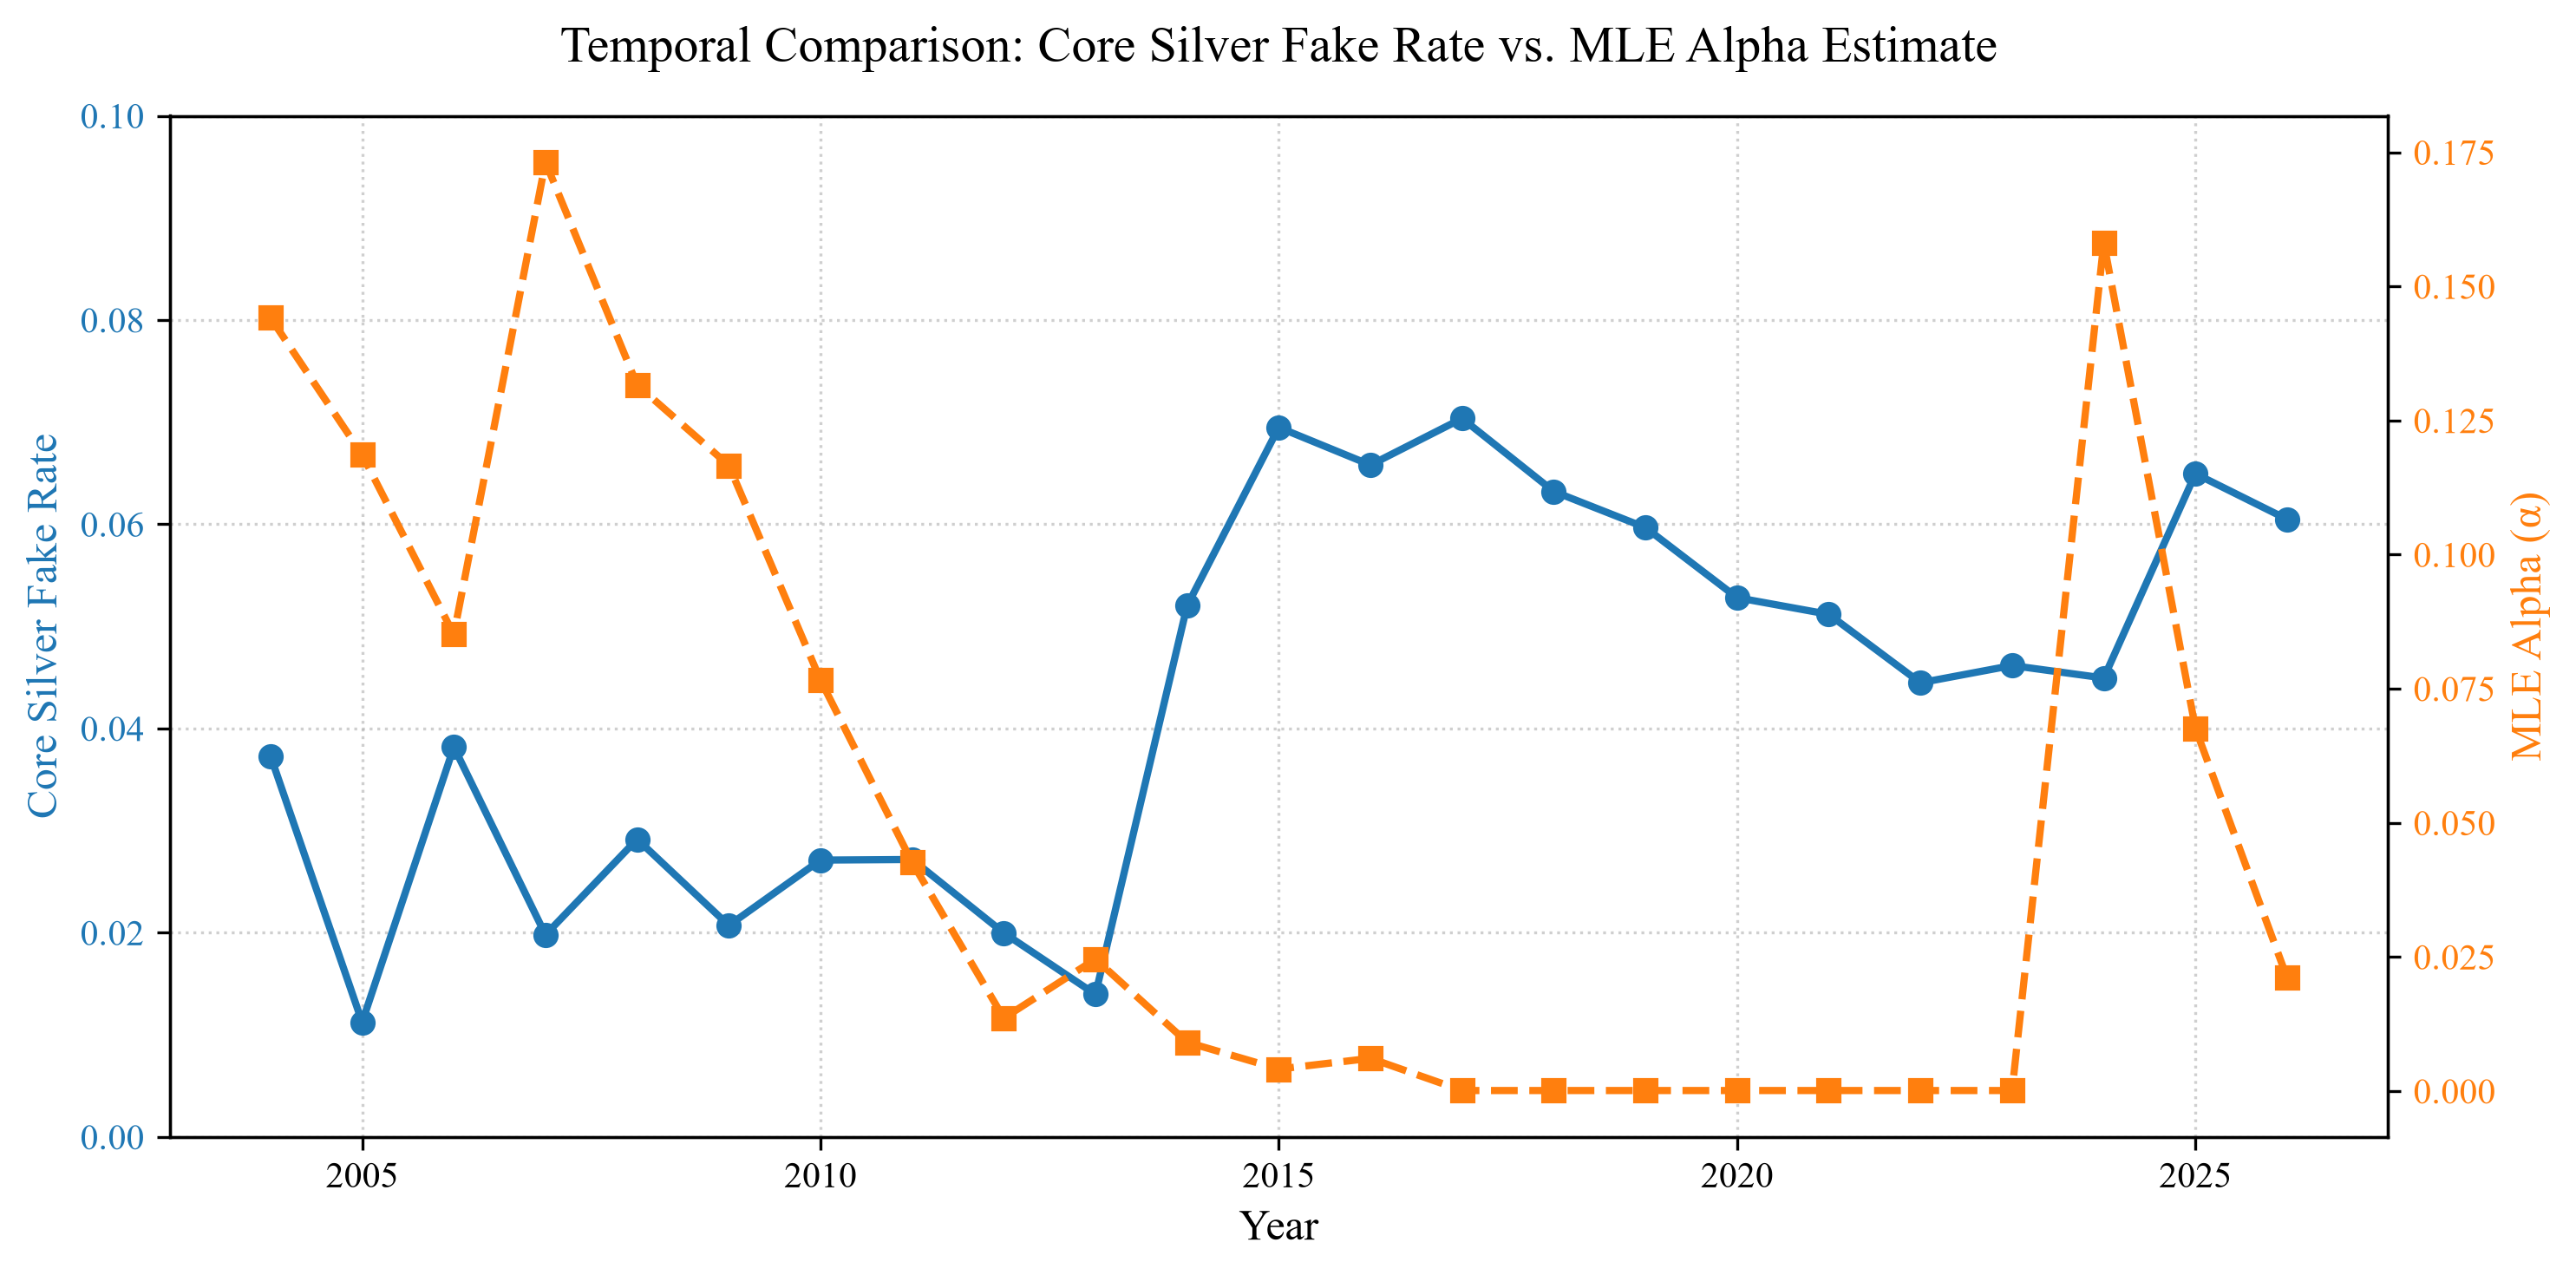

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the comparison data (saved earlier)
df = pd.read_csv(r"C:\Users\Admin\Downloads\rq1_mle_vs_silver_comparison.csv")

# Only keep meaningful years (e.g. 2014 onward)
df_plot = df[df["n_mle"] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# Left axis: Core Silver Fake Rate
color = "tab:blue"
ax1.set_xlabel("Year", fontsize=12, fontname="Times New Roman")
ax1.set_ylabel(
    "Core Silver Fake Rate", color=color, fontsize=12, fontname="Times New Roman"
)
line1 = ax1.plot(
    df_plot["year"],
    df_plot["core_silver_fake_rate"],
    color=color,
    marker="o",
    linewidth=2,
    label="Silver Fake Rate",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_ylim(0, 0.10)

# Right axis: MLE Alpha
ax2 = (
    ax1.twinx()
)  # add a second Y axis sharing the same X axis
color = "tab:orange"
ax2.set_ylabel(
    "MLE Alpha (α)", color=color, fontsize=12, fontname="Times New Roman"
)
line2 = ax2.plot(
    df_plot["year"],
    df_plot["mle_alpha"],
    color=color,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="MLE Alpha",
)
ax2.tick_params(axis="y", labelcolor=color)

# Title and grid
plt.title(
    "Temporal Comparison: Core Silver Fake Rate vs. MLE Alpha Estimate",
    fontsize=14,
    fontname="Times New Roman",
    pad=15,
)
ax1.grid(True, linestyle=":", alpha=0.6)

# set the font to Times New Roman
for label in (
    ax1.get_xticklabels()
    + ax1.get_yticklabels()
    + ax2.get_yticklabels()
):
    label.set_fontname("Times New Roman")

fig.tight_layout()
plt.savefig(
    r"C:\Users\Admin\Downloads\rq1_comparison_trend_chart.png", dpi=300
)
plt.show()

## 10. Source Batch Distribution Chart

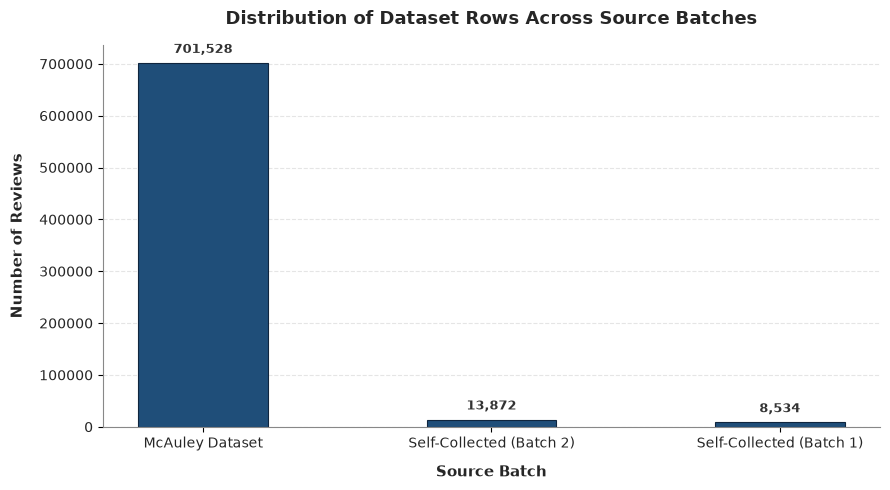

In [38]:
import matplotlib.pyplot as plt

# ============================================================
# Source batch distribution data
# ============================================================
batches = ["McAuley Dataset", "Self-Collected (Batch 2)", "Self-Collected (Batch 1)"]
counts = [701528, 13872, 8534]

# ============================================================
# Academic-style bar chart
# ============================================================
plt.figure(figsize=(9, 5), facecolor="white")
ax = plt.axes()
ax.set_facecolor("white")

bar_color = "#1f4e79"  # academic blue

bars = plt.bar(
    batches,
    counts,
    color=bar_color,
    edgecolor="#0f253e",
    linewidth=0.8,
    width=0.45,  # kept balanced for 3 bars
)

# Title and labels
plt.title(
    "Distribution of Dataset Rows Across Source Batches",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="#262626",
)
plt.xlabel(
    "Source Batch", fontsize=11, fontweight="bold", labelpad=10, color="#262626"
)
plt.ylabel(
    "Number of Reviews",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#262626",
)

# Axis formatting
plt.xticks(fontsize=10, color="#262626")
plt.yticks(fontsize=10, color="#262626")

# Grid lines (background guide)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)

# Clean up frame (remove top/right lines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")

# Add number labels above the bars
for bar in bars:
  height = bar.get_height()
  plt.annotate(
      f"{height:,}",
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),  # small gap above the bar
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontsize=9.5,
      fontweight="bold",
      color="#333333",
  )

plt.tight_layout()

# If you want to save at high resolution (300 DPI):
# plt.savefig(r"C:\Users\Admin\Downloads\source_batch_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

## 11. MLE Computation, Continued

In [14]:
import pandas as pd
import numpy as np

# ============================================================
# 1) Load data
# ============================================================
COMBINED_PATH = r"C:\Users\Admin\Downloads\combined_silver_labeled.csv"
SYNTHETIC_PATH = r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv"

combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")
synthetic = pd.read_csv(SYNTHETIC_PATH, encoding="utf-8-sig")

print("Combined rows:", len(combined))
print("Synthetic rows:", len(synthetic))

# ============================================================
# 2) Vocabulary — known LLM-overused words (Juzek & Ward, 2024)
#    No POS tagger needed, avoids spaCy/sklearn dependency issues
# ============================================================
VOCAB = [
    "delve", "delves", "delved", "delving",
    "intricate", "intricacies",
    "underscore", "underscores", "underscoring",
    "boasts", "garnered", "meticulous", "methodical",
    "realm", "notable", "comprehensive", "valuable",
    "additionally", "particularly", "effectively", "potentially",
    "successfully", "thereby", "convincingly",
    "showcase", "showcases", "showcasing",
    "pivotal", "robust", "noteworthy", "testament",
]

# ============================================================
# 3) Reference distributions
#    P = human-written reference (organic rows NOT flagged as suspicious)
#    Q = AI-generated reference (our synthetic set)
# ============================================================
p_ref_texts = combined.loc[~combined["core_silver_fake"].astype(bool), "text_en"].dropna()
q_ref_texts = synthetic["text_en"].dropna()

print(f"\nP (human) reference size: {len(p_ref_texts)}")
print(f"Q (AI) reference size: {len(q_ref_texts)}")

def occurrence_probs(texts, vocab):
    """For each vocab word, what fraction of documents contain it (whole-word match)."""
    texts_lower = texts.str.lower().fillna("")
    n = len(texts_lower)
    probs = {}
    for word in vocab:
        count = texts_lower.str.contains(rf"\b{word}\b", regex=True).sum()
        p = count / n
        probs[word] = min(max(p, 1e-6), 1 - 1e-6)  # avoid exact 0 or 1
    return probs

p_hat = occurrence_probs(p_ref_texts, VOCAB)
q_hat = occurrence_probs(q_ref_texts, VOCAB)

print("\np_hat (organic/human):")
print(pd.Series(p_hat).sort_values(ascending=False))
print("\nq_hat (synthetic/AI):")
print(pd.Series(q_hat).sort_values(ascending=False))

# ============================================================
# 4) Vectorized per-document log-likelihood under P and Q
# ============================================================
def build_presence_matrix(texts, vocab):
    texts_lower = texts.str.lower().fillna("")
    presence = np.zeros((len(texts_lower), len(vocab)), dtype=bool)
    for j, word in enumerate(vocab):
        presence[:, j] = texts_lower.str.contains(rf"\b{word}\b", regex=True).values
    return presence

def doc_log_likelihoods(presence, probs_dict, vocab):
    p_arr = np.array([probs_dict[w] for w in vocab])
    log_p = np.log(p_arr)
    log_1mp = np.log(1 - p_arr)
    ll = presence.astype(float) @ log_p + (~presence).astype(float) @ log_1mp
    return ll

# ============================================================
# 5) MLE alpha via grid search (no scipy needed)
# ============================================================
def estimate_alpha(logP, logQ, grid_size=2000):
    P = np.exp(logP)
    Q = np.exp(logQ)
    alphas = np.linspace(0.0001, 0.9999, grid_size)
    best_alpha, best_ll = 0.0, -np.inf
    for a in alphas:
        mix = (1 - a) * P + a * Q
        mix = np.clip(mix, 1e-300, None)
        ll = np.sum(np.log(mix))
        if ll > best_ll:
            best_ll = ll
            best_alpha = a
    return best_alpha

# ============================================================
# 6) Apply per year — this is the actual RQ1 result
# ============================================================
results = {}
for year in sorted(combined["year"].dropna().unique()):
    year_texts = combined.loc[combined["year"] == year, "text_en"].dropna()
    if len(year_texts) < 20:
        continue
    presence = build_presence_matrix(year_texts, VOCAB)
    logP = doc_log_likelihoods(presence, p_hat, VOCAB)
    logQ = doc_log_likelihoods(presence, q_hat, VOCAB)
    alpha = estimate_alpha(logP, logQ)
    results[int(year)] = {"alpha": alpha, "n": len(year_texts)}

results_df = pd.DataFrame(results).T.sort_index()
print("\n=== RQ1 RESULT: Estimated AI-influence proportion (alpha) by year ===")
print(results_df)

results_df.to_csv(r"C:\Users\Admin\Downloads\rq1_mle_results_by_year.csv")
print("\nSaved: rq1_mle_results_by_year.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16728\610015651.py:10: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")


Combined rows: 723934
Synthetic rows: 450

P (human) reference size: 680530
Q (AI) reference size: 450

p_hat (organic/human):
particularly     0.001494
effectively      0.000739
additionally     0.000392
successfully     0.000260
robust           0.000216
potentially      0.000200
valuable         0.000173
intricate        0.000065
notable          0.000060
comprehensive    0.000051
thereby          0.000044
boasts           0.000031
testament        0.000029
showcase         0.000026
meticulous       0.000025
realm            0.000021
noteworthy       0.000021
convincingly     0.000007
showcasing       0.000007
showcases        0.000006
delve            0.000004
garnered         0.000004
intricacies      0.000003
pivotal          0.000003
underscore       0.000001
underscores      0.000001
delved           0.000001
methodical       0.000001
underscoring     0.000001
delves           0.000001
delving          0.000001
dtype: float64

q_hat (synthetic/AI):
effectively      0.028889
rob

## 11b. MLE Computation, Continued

In [15]:
import pandas as pd
import numpy as np

# ============================================================
# 1) Load data
# ============================================================
COMBINED_PATH = r"C:\Users\Admin\Downloads\combined_silver_labeled.csv"
SYNTHETIC_PATH = r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv"

combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")
synthetic = pd.read_csv(SYNTHETIC_PATH, encoding="utf-8-sig")

print("Combined rows (all languages):", len(combined))

# ============================================================
# 1b) ENGLISH-ONLY FILTER — this is the key change.
#     Restricting to detected_lang == 'en' removes any row whose
#     text_en came from machine translation, isolating whether the
#     RQ1 trend still appears without the translation confound.
# ============================================================
combined_en = combined[combined["detected_lang"] == "en"].copy()
print("\nRows with detected_lang == 'en':", len(combined_en))
print("\nRow count by year (English-only):")
print(combined_en.groupby("year").size())

# ============================================================
# 2) Vocabulary — known LLM-overused words (Juzek & Ward, 2024)
# ============================================================
VOCAB = [
    "delve", "delves", "delved", "delving",
    "intricate", "intricacies",
    "underscore", "underscores", "underscoring",
    "boasts", "garnered", "meticulous", "methodical",
    "realm", "notable", "comprehensive", "valuable",
    "additionally", "particularly", "effectively", "potentially",
    "successfully", "thereby", "convincingly",
    "showcase", "showcases", "showcasing",
    "pivotal", "robust", "noteworthy", "testament",
]

# ============================================================
# 3) Reference distributions
#    P = human-written reference, English-only (organic rows NOT
#        flagged as suspicious, AND detected_lang == 'en' — kept
#        translation-free to match Q, which is also English-only)
#    Q = AI-generated reference (our synthetic set, English-only)
# ============================================================
p_ref_texts = combined_en.loc[~combined_en["core_silver_fake"].astype(bool), "text_en"].dropna()
q_ref_texts = synthetic["text_en"].dropna()

print(f"\nP (human, English-only) reference size: {len(p_ref_texts)}")
print(f"Q (AI) reference size: {len(q_ref_texts)}")

def occurrence_probs(texts, vocab):
    texts_lower = texts.str.lower().fillna("")
    n = len(texts_lower)
    probs = {}
    for word in vocab:
        count = texts_lower.str.contains(rf"\b{word}\b", regex=True).sum()
        p = count / n
        probs[word] = min(max(p, 1e-6), 1 - 1e-6)
    return probs

p_hat = occurrence_probs(p_ref_texts, VOCAB)
q_hat = occurrence_probs(q_ref_texts, VOCAB)

print("\np_hat (organic/human, English-only):")
print(pd.Series(p_hat).sort_values(ascending=False))
print("\nq_hat (synthetic/AI):")
print(pd.Series(q_hat).sort_values(ascending=False))

# ============================================================
# 4) Vectorized per-document log-likelihood under P and Q
# ============================================================
def build_presence_matrix(texts, vocab):
    texts_lower = texts.str.lower().fillna("")
    presence = np.zeros((len(texts_lower), len(vocab)), dtype=bool)
    for j, word in enumerate(vocab):
        presence[:, j] = texts_lower.str.contains(rf"\b{word}\b", regex=True).values
    return presence

def doc_log_likelihoods(presence, probs_dict, vocab):
    p_arr = np.array([probs_dict[w] for w in vocab])
    log_p = np.log(p_arr)
    log_1mp = np.log(1 - p_arr)
    ll = presence.astype(float) @ log_p + (~presence).astype(float) @ log_1mp
    return ll

# ============================================================
# 5) MLE alpha via grid search
# ============================================================
def estimate_alpha(logP, logQ, grid_size=2000):
    P = np.exp(logP)
    Q = np.exp(logQ)
    alphas = np.linspace(0.0001, 0.9999, grid_size)
    best_alpha, best_ll = 0.0, -np.inf
    for a in alphas:
        mix = (1 - a) * P + a * Q
        mix = np.clip(mix, 1e-300, None)
        ll = np.sum(np.log(mix))
        if ll > best_ll:
            best_ll = ll
            best_alpha = a
    return best_alpha

# ============================================================
# 6) Apply per year — ENGLISH-ONLY subset this time
# ============================================================
results = {}
for year in sorted(combined_en["year"].dropna().unique()):
    year_texts = combined_en.loc[combined_en["year"] == year, "text_en"].dropna()
    n = len(year_texts)
    if n < 20:
        continue
    presence = build_presence_matrix(year_texts, VOCAB)
    logP = doc_log_likelihoods(presence, p_hat, VOCAB)
    logQ = doc_log_likelihoods(presence, q_hat, VOCAB)
    alpha = estimate_alpha(logP, logQ)
    results[int(year)] = {"alpha": alpha, "n": n}

results_df = pd.DataFrame(results).T.sort_index()
print("\n=== RQ1 RESULT (ENGLISH-ONLY SUBSET): Estimated alpha by year ===")
print(results_df)

results_df.to_csv(r"C:\Users\Admin\Downloads\rq1_mle_results_by_year_ENGLISH_ONLY.csv")
print("\nSaved: rq1_mle_results_by_year_ENGLISH_ONLY.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16728\3118125618.py:10: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")


Combined rows (all languages): 723934

Rows with detected_lang == 'en': 703636

Row count by year (English-only):
year
2000         1
2001        12
2002        24
2003        56
2004       134
2005       267
2006       419
2007      1162
2008      1269
2009      1207
2010      1586
2011      1877
2012      2803
2013      7948
2014     16279
2015     36239
2016     62747
2017     68035
2018     72707
2019     99120
2020    126753
2021    124897
2022     61581
2023     14405
2024       267
2025       816
2026      1025
dtype: int64

P (human, English-only) reference size: 663023
Q (AI) reference size: 450

p_hat (organic/human, English-only):
particularly     0.001124
effectively      0.000722
additionally     0.000400
successfully     0.000262
potentially      0.000202
valuable         0.000137
robust           0.000118
intricate        0.000066
notable          0.000062
comprehensive    0.000048
thereby          0.000045
boasts           0.000032
testament        0.000030
showcase    

## 12. English Reviews by Year Bar Chart

C:\Users\Admin\AppData\Local\Temp\ipykernel_5740\3972670876.py:8: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")


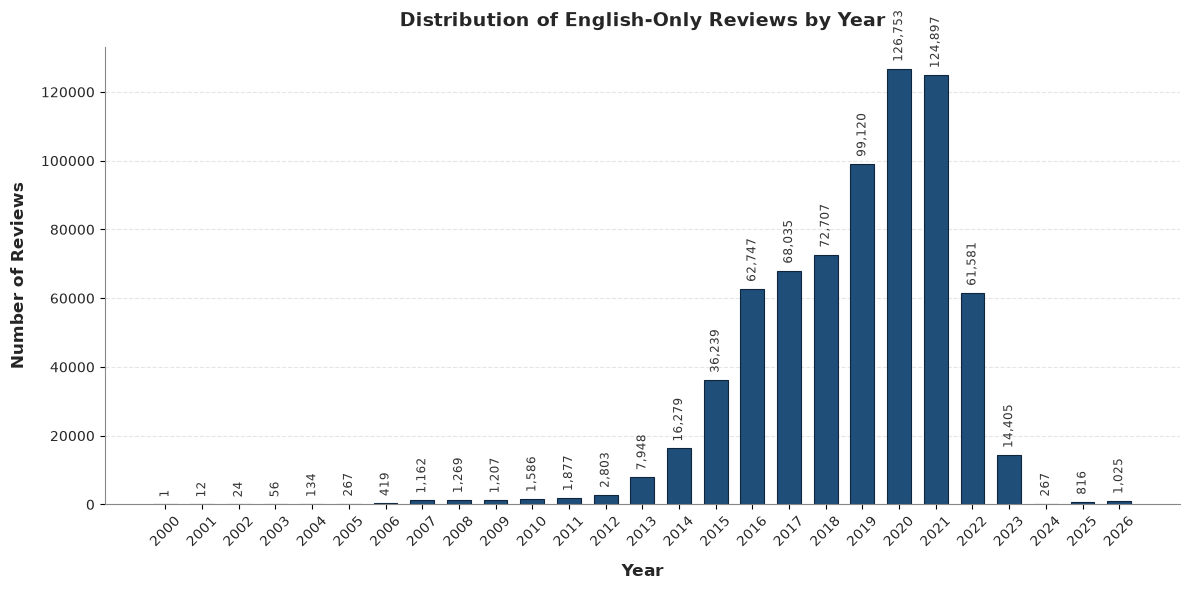

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1) Load and filter the data
# ============================================================
COMBINED_PATH = r"C:\Users\Admin\Downloads\combined_silver_labeled.csv"
combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")

# Keep only English-language reviews
combined_en = combined[combined["detected_lang"] == "en"].copy()

# Get counts by year
year_counts = combined_en.groupby("year").size()

# ============================================================
# 2) Academic-style bar chart - vertical labels
# ============================================================
plt.figure(figsize=(12, 6), facecolor="white")  # a bit wider
ax = plt.axes()
ax.set_facecolor("white")

bar_color = "#1f4e79"

# Build the bar chart
bars = plt.bar(
    year_counts.index.astype(str),
    year_counts.values,
    color=bar_color,
    edgecolor="#0f253e",
    linewidth=0.8,
    width=0.65,
)

# Title and axis labels
plt.title(
    "Distribution of English-Only Reviews by Year",
    fontsize=14,
    fontweight="bold",
    pad=15,
    color="#262626",
)
plt.xlabel("Year", fontsize=12, fontweight="bold", labelpad=10, color="#262626")
plt.ylabel(
    "Number of Reviews", fontsize=12, fontweight="bold", labelpad=10, color="#262626"
)

# Axis formatting
plt.xticks(fontsize=10, rotation=45, color="#262626")
plt.yticks(fontsize=10, color="#262626")

# Grid lines
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)

# Frame cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")

# ROTATE AND POSITION THE NUMBERS VERTICALLY:
for bar in bars:
  height = bar.get_height()
  plt.annotate(
      f"{height:,}",
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(
          0,
          5,
      ),  # start just above the bar (avoids overlap with vertical text)
      textcoords="offset points",
      ha="center",
      va="bottom",
      rotation=90,  # rotate the numbers vertically
      fontsize=8.5,
      color="#333333",
  )

plt.tight_layout()

# If you want to save at high resolution:
plt.savefig(
    r"C:\Users\Admin\Downloads\english_reviews_by_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 13. Bootstrap Confidence Intervals for MLE Alpha

In [16]:
def bootstrap_alpha_ci(year_texts, p_hat, q_hat, vocab, n_boot=200, seed=42):
    rng = np.random.RandomState(seed)
    n = len(year_texts)
    alphas = []
    for _ in range(n_boot):
        sample = year_texts.sample(n=n, replace=True, random_state=rng.randint(0, 1_000_000))
        presence = build_presence_matrix(sample, vocab)
        logP = doc_log_likelihoods(presence, p_hat, vocab)
        logQ = doc_log_likelihoods(presence, q_hat, vocab)
        alphas.append(estimate_alpha(logP, logQ))
    alphas = np.array(alphas)
    return np.percentile(alphas, 2.5), np.median(alphas), np.percentile(alphas, 97.5)

for year in [2022, 2023, 2024, 2025, 2026]:
    year_texts = combined_en.loc[combined_en["year"] == year, "text_en"].dropna()
    lo, med, hi = bootstrap_alpha_ci(year_texts, p_hat, q_hat, VOCAB, n_boot=200)
    print(f"{year}: median α={med:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}], n={len(year_texts)}")

2022: median α=0.0001, 95% CI=[0.0001, 0.0001], n=61262
2023: median α=0.0001, 95% CI=[0.0001, 0.0116], n=14338
2024: median α=0.1581, 95% CI=[0.0001, 0.4347], n=267
2025: median α=0.0621, 95% CI=[0.0001, 0.1849], n=816
2026: median α=0.0211, 95% CI=[0.0001, 0.0911], n=1025


## 14. MLE Results by Year (Full Table)

In [17]:
import pandas as pd
import numpy as np

# ============================================================
# Load both result sets
# ============================================================
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
mle_results = pd.read_csv(r"C:\Users\Admin\Downloads\rq1_mle_results_by_year_ENGLISH_ONLY.csv", index_col=0)
mle_results.index.name = "year"
mle_results.index = mle_results.index.astype(int)

# ============================================================
# Compute core_silver_fake rate on the SAME subset the MLE used
# (English-only), so the two trends are directly comparable
# ============================================================
combined_en = combined[combined["detected_lang"] == "en"].copy()

silver_by_year = combined_en.groupby("year")["core_silver_fake"].agg(["mean", "count"])
silver_by_year.columns = ["core_silver_fake_rate", "n_silver"]
silver_by_year.index = silver_by_year.index.astype(int)

# ============================================================
# Merge and compare side by side
# ============================================================
comparison = mle_results.join(silver_by_year, how="inner")
comparison = comparison.rename(columns={"alpha": "mle_alpha", "n": "n_mle"})

print("=== RQ1: MLE alpha vs. core_silver_fake rate, by year (English-only) ===\n")
print(comparison[["mle_alpha", "n_mle", "core_silver_fake_rate", "n_silver"]])

# ============================================================
# Correlation between the two independent signals
# ============================================================
# Only years with a reasonably sized sample are meaningful for this check
reliable = comparison[comparison["n_mle"] >= 100]
if len(reliable) >= 3:
    corr = reliable["mle_alpha"].corr(reliable["core_silver_fake_rate"])
    print(f"\nPearson correlation (years with n>=100 only): r = {corr:.3f}")
else:
    print("\nNot enough well-sampled years to compute a meaningful correlation.")

comparison.to_csv(r"C:\Users\Admin\Downloads\rq1_mle_vs_silver_comparison.csv")
print("\nSaved: rq1_mle_vs_silver_comparison.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16728\4171065475.py:7: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")


=== RQ1: MLE alpha vs. core_silver_fake rate, by year (English-only) ===

      mle_alpha     n_mle  core_silver_fake_rate  n_silver
year                                                      
2002   0.999400      24.0               0.000000        24
2003   0.000100      56.0               0.017857        56
2004   0.144143     134.0               0.037313       134
2005   0.118636     267.0               0.011236       267
2006   0.085126     419.0               0.038186       419
2007   0.173152    1162.0               0.019793      1162
2008   0.131639    1269.0               0.029157      1269
2009   0.116635    1207.0               0.020713      1207
2010   0.076623    1586.0               0.027112      1586
2011   0.042613    1877.0               0.027171      1877
2012   0.013604    2803.0               0.019979      2803
2013   0.024607    7948.0               0.013966      7948
2014   0.009103   16279.0               0.052030     16279
2015   0.004101   36229.0               0

## 15. MLE vs. Silver-Label Comparison Plot

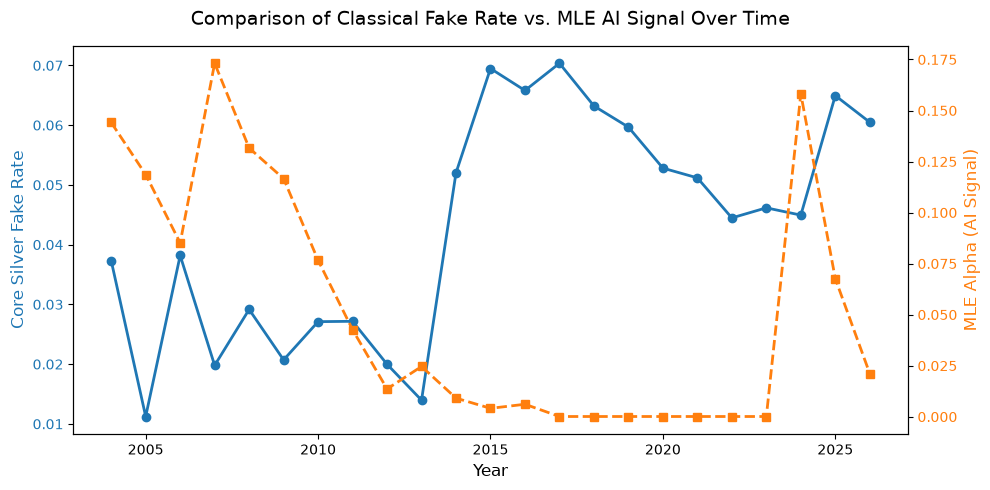

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the saved file
df = pd.read_csv(r"C:\Users\Admin\Downloads\rq1_mle_vs_silver_comparison.csv", index_col="year")

# Filter to reliable years with n >= 100
reliable = df[df["n_mle"] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: core_silver_fake_rate
color = "tab:blue"
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Core Silver Fake Rate", color=color, fontsize=12)
line1 = ax1.plot(reliable.index, reliable["core_silver_fake_rate"], color=color, marker="o", linewidth=2, label="Core Silver Fake Rate")
ax1.tick_params(axis="y", labelcolor=color)

# Right axis: mle_alpha
ax2 = ax1.twinx()  
color = "tab:orange"
ax2.set_ylabel("MLE Alpha (AI Signal)", color=color, fontsize=12)
line2 = ax2.plot(reliable.index, reliable["mle_alpha"], color=color, marker="s", linestyle="--", linewidth=2, label="MLE Alpha")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Comparison of Classical Fake Rate vs. MLE AI Signal Over Time", fontsize=14, pad=15)
fig.tight_layout()

# Save as an image
plt.savefig(r"C:\Users\Admin\Downloads\mle_vs_silver_trend.png", dpi=300)
plt.show()

## 16. RQ1 Summary Table (2002 / 2017-2023 / 2024-2026)

In [41]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Load both result sets and create 'comparison'
# ============================================================
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
mle_results = pd.read_csv(r"C:\Users\Admin\Downloads\rq1_mle_results_by_year_ENGLISH_ONLY.csv", index_col=0)
mle_results.index.name = "year"
mle_results.index = mle_results.index.astype(int)

# Compute core_silver_fake rate on the English-only subset
combined_en = combined[combined["detected_lang"] == "en"].copy()
silver_by_year = combined_en.groupby("year")["core_silver_fake"].agg(["mean", "count"])
silver_by_year.columns = ["core_silver_fake_rate", "n_silver"]
silver_by_year.index = silver_by_year.index.astype(int)

# Merge side by side
comparison = mle_results.join(silver_by_year, how="inner")
comparison = comparison.rename(columns={"alpha": "mle_alpha", "n": "n_mle"})

# ============================================================
# 2. Build the summary table based on 'comparison'
# ============================================================
summary_rows = []

# 1. Year 2002 (exceptional / small sample)
if 2002 in comparison.index:
    summary_rows.append({
        "Year / Period": "2002",
        "Sample Size (n)": f"{comparison.loc[2002, 'n_mle']:,}",
        "MLE Alpha (α)": f"{comparison.loc[2002, 'mle_alpha']:.3f}",
        "Silver Fake Rate": f"{comparison.loc[2002, 'core_silver_fake_rate']:.3f}",
        "Evaluation / Status": "Unstable (Too small sample)"
    })

# 2. 2017-2023 period (stable baseline)
baseline = comparison.loc[comparison.index.isin(range(2017, 2024))]
if not baseline.empty:
    min_n, max_n = baseline["n_mle"].min(), baseline["n_mle"].max()
    summary_rows.append({
        "Year / Period": "2017–2023",
        "Sample Size (n)": f"{min_n:,} – {max_n:,}",
        "MLE Alpha (α)": "Near zero (~0)",
        "Silver Fake Rate": f"{baseline['core_silver_fake_rate'].mean():.3f} (Avg)",
        "Evaluation / Status": "Stable baseline period"
    })

# 3. 2024, 2025, 2026 - critical years
eval_notes = {
    2024: "Wide interval, suggestive",
    2025: "Intermediate",
    2026: "Declining toward baseline"
}

for yr in [2024, 2025, 2026]:
    if yr in comparison.index:
        summary_rows.append({
            "Year / Period": str(yr),
            "Sample Size (n)": f"{comparison.loc[yr, 'n_mle']:,}",
            "MLE Alpha (α)": f"{comparison.loc[yr, 'mle_alpha']:.3f}",
            "Silver Fake Rate": f"{comparison.loc[yr, 'core_silver_fake_rate']:.3f}",
            "Evaluation / Status": eval_notes.get(yr, "")
        })

# Final summary DataFrame
summary_table = pd.DataFrame(summary_rows)

print("\n" + "="*80)
print("RQ1: SUMMARY MLE ALPHA & SILVER FAKE RATE TABLE")
print("="*80)
print(summary_table.to_markdown(index=False))
print("="*80)

# Save as CSV:
summary_table.to_csv(r"C:\Users\Admin\Downloads\rq1_summary_table.csv", index=False)
print("\nSaved: rq1_summary_table.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_5740\393027083.py:7: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")



RQ1: SUMMARY MLE ALPHA & SILVER FAKE RATE TABLE
| Year / Period   | Sample Size (n)      | MLE Alpha (α)   | Silver Fake Rate   | Evaluation / Status         |
|:----------------|:---------------------|:----------------|:-------------------|:----------------------------|
| 2002            | 24.0                 | 0.999           | 0.000              | Unstable (Too small sample) |
| 2017–2023       | 14,338.0 – 126,719.0 | Near zero (~0)  | 0.055 (Avg)        | Stable baseline period      |
| 2024            | 267.0                | 0.158           | 0.045              | Wide interval, suggestive   |
| 2025            | 816.0                | 0.068           | 0.065              | Intermediate                |
| 2026            | 1,025.0              | 0.021           | 0.060              | Declining toward baseline   |

Saved: rq1_summary_table.csv


## 17. LLM-Judge Scoring of Synthetic Review Quality

In [19]:
import pandas as pd
import time
from openai import OpenAI
from tqdm import tqdm

client = OpenAI(api_key="sk-your-api-key")

synthetic = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv", encoding="utf-8-sig")

# --- FIX: recover the real product title by joining on asin ---
merged = pd.read_csv(r"C:\Users\Admin\Downloads\all_beauty_reviews_2024_2026_merged_final.csv", encoding="utf-8-sig")
asin_title_map = merged.drop_duplicates(subset="asin").set_index("asin")["title"].to_dict()
synthetic["product_title"] = synthetic["asin"].map(asin_title_map).fillna("(product title unavailable)")

print("Rows with missing product title:", (synthetic["product_title"] == "(product title unavailable)").sum())

# ============================================================
# PART 1 — LLM-judge persuasiveness scoring
# ============================================================
JUDGE_MODEL = "gpt-4o-mini"

def build_judge_prompt(product_title, review_text):
    return f"""Please read the following product review for "{product_title}":

"{review_text}"

Rate this review on the following five dimensions, each from 1 (totally no) to 5 (totally yes):
1. Is it clearly positive?
2. Is it detailed?
3. Is it convincing?
4. Does it read as if written by a typical human customer?
5. Would it be influential to a potential buyer?

Respond in EXACTLY this format, nothing else:
POSITIVE: <1-5>
DETAILED: <1-5>
CONVINCING: <1-5>
HUMAN_LIKE: <1-5>
INFLUENTIAL: <1-5>"""

def call_judge(prompt, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=100,
                temperature=0,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt == max_retries - 1:
                return None
            time.sleep(2)

def parse_judge_scores(raw):
    scores = {}
    if raw is None:
        return scores
    for line in raw.split("\n"):
        for key in ["POSITIVE", "DETAILED", "CONVINCING", "HUMAN_LIKE", "INFLUENTIAL"]:
            if line.strip().startswith(key + ":"):
                try:
                    scores[key.lower()] = int(line.split(":", 1)[1].strip()[0])
                except (ValueError, IndexError):
                    pass
    return scores

judge_results = []
n_judge_failed = 0
for _, row in tqdm(synthetic.iterrows(), total=len(synthetic), desc="Judging synthetic reviews"):
    prompt = build_judge_prompt(row["product_title"], row["text"])
    raw = call_judge(prompt)
    scores = parse_judge_scores(raw)
    if not scores:
        n_judge_failed += 1
    scores["asin"] = row["asin"]
    scores["generator_label"] = row["generator_label"]
    judge_results.append(scores)
    time.sleep(0.3)

judge_df = pd.DataFrame(judge_results)
print(f"\nJudge calls with no usable score: {n_judge_failed}/{len(synthetic)}")
print("\n=== LLM-Judge Persuasiveness Scores (mean by generator) ===")
print(judge_df.groupby("generator_label")[["positive", "detailed", "convincing", "human_like", "influential"]].mean())

judge_df.to_csv(r"C:\Users\Admin\Downloads\synthetic_judge_scores.csv", index=False, encoding="utf-8-sig")
print("Saved: synthetic_judge_scores.csv")


# ============================================================
# PART 2 — Pairwise BLEU diversity, within each generator
# ============================================================
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from itertools import combinations
import random

smoothie = SmoothingFunction().method4

def pairwise_bleu_sample(texts, n_pairs=500, seed=42):
    rng = random.Random(seed)
    tokenized = [t.split() for t in texts]
    all_pairs = list(combinations(range(len(tokenized)), 2))
    sample_pairs = rng.sample(all_pairs, min(n_pairs, len(all_pairs)))
    scores = [sentence_bleu([tokenized[i]], tokenized[j], smoothing_function=smoothie) for i, j in sample_pairs]
    return sum(scores) / len(scores)

print("\n=== Pairwise BLEU diversity (lower = more diverse) ===")
for gen_label, group in synthetic.groupby("generator_label"):
    avg_bleu = pairwise_bleu_sample(group["text"].tolist())
    print(f"{gen_label}: avg pairwise BLEU = {avg_bleu:.4f}  (n={len(group)})")

Rows with missing product title: 0


Judging synthetic reviews: 100%|██████████| 450/450 [11:44<00:00,  1.56s/it]



Judge calls with no usable score: 0/450

=== LLM-Judge Persuasiveness Scores (mean by generator) ===
                 positive  detailed  convincing  human_like  influential
generator_label                                                         
new_strong            5.0  3.751111    4.680000    4.977778     4.737778
old_weak              5.0  3.573333    4.546667    4.995556     4.573333
Saved: synthetic_judge_scores.csv

=== Pairwise BLEU diversity (lower = more diverse) ===
new_strong: avg pairwise BLEU = 0.0342  (n=225)
old_weak: avg pairwise BLEU = 0.0540  (n=225)


## 18. Synthetic Validation Summary Table

In [61]:
import pandas as pd

# Define the summary data as a dictionary
data = {
    "Metric_Dimension": [
        "Positive Persuasion", 
        "Human-likeness", 
        "Convincingness", 
        "Detail Level", 
        "Influence Score", 
        "Pairwise BLEU Diversity"
    ],
    "Newer_Generator_gpt4o": [5.00, 4.98, 4.68, 3.75, 4.74, 0.034],
    "Older_Generator_gpt3.5": [5.00, 5.00, 4.55, 3.57, 4.57, 0.054],
    "Difference": [0.00, -0.02, 0.13, 0.18, 0.17, -0.020]
}

df_summary = pd.DataFrame(data)

# Save as CSV (utf-8-sig so characters don't break in Excel)
df_summary.to_csv("synthetic_validation_summary.csv", index=False, encoding="utf-8-sig")

print("Summary table saved successfully as 'synthetic_validation_summary.csv'!")
print(df_summary)

Summary table saved successfully as 'synthetic_validation_summary.csv'!
          Metric_Dimension  Newer_Generator_gpt4o  Older_Generator_gpt3.5  \
0      Positive Persuasion                  5.000                   5.000   
1           Human-likeness                  4.980                   5.000   
2           Convincingness                  4.680                   4.550   
3             Detail Level                  3.750                   3.570   
4          Influence Score                  4.740                   4.570   
5  Pairwise BLEU Diversity                  0.034                   0.054   

   Difference  
0        0.00  
1       -0.02  
2        0.13  
3        0.18  
4        0.17  
5       -0.02  


## 19. Additional Checks (Hour of Day, Combined Data)

In [20]:
df["hour_of_day"] = pd.to_datetime(df["unix_time"], unit="s").dt.hour
print(df.groupby("source_batch")["hour_of_day"].value_counts(normalize=True).head(20))

source_batch  hour_of_day
batch1        0              1.000000
batch2        0              1.000000
mcauley       18             0.067362
              19             0.062743
              17             0.061616
              20             0.059298
              21             0.055472
              1              0.054726
              0              0.054530
              2              0.054139
              22             0.054032
              23             0.053432
              16             0.052743
              15             0.050533
              3              0.047884
              14             0.046712
              13             0.039802
              4              0.037611
              12             0.029892
              5              0.028042
Name: proportion, dtype: float64


In [21]:
print(combined_en.groupby("year").size().head(5))

year
2000      1
2001     12
2002     24
2003     56
2004    134
dtype: int64


## 20. Logistic Regression Raw Yearly Trend (RQ1 Robustness Check)

In [24]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ============================================================
# 1) Load data, restrict to English-language subset
# ============================================================
df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
df_en = df[df["detected_lang"] == "en"].copy()

# force to integer 0/1, not boolean
df_en["core_silver_fake"] = df_en["core_silver_fake"].astype(int)

# ============================================================
# 2) Year-level summary stats (for reference/reporting)
# ============================================================
yearly = df_en.groupby("year").agg(
    annual_volume=("asin", "count"),
    verified_rate=("verified", "mean"),
    mean_rating=("rating", "mean"),
    silver_fake_rate=("core_silver_fake", "mean"),
).reset_index()

print(yearly)

# ============================================================
# 3) Merge year-level aggregates back onto row-level data
# ============================================================
row_level = df_en.merge(yearly[["year", "annual_volume", "verified_rate", "mean_rating"]], on="year")

# ============================================================
# 4) Fit the logistic regression
# ============================================================
model = smf.logit(
    "core_silver_fake ~ year + annual_volume + verified_rate + mean_rating",
    data=row_level
).fit()

# ============================================================
# 5) Extract results manually — avoids model.summary(), which
#    crashes on this machine due to a broken scipy.stats install
#    (same underlying DLL/Application Control issue seen earlier
#    with scikit-learn)
# ============================================================
print("\n=== Model Results (manual extraction, no .summary()) ===\n")
print("Coefficients:")
print(model.params)
print("\nStandard errors:")
print(model.bse)
print("\nP-values:")
print(model.pvalues)
print("\nPseudo R-squared:", model.prsquared)
print("Log-Likelihood:", model.llf)
print("No. Observations:", int(model.nobs))

print("\n--- Year effect specifically ---")
print("Year coefficient:", model.params["year"])
print("Year p-value:", model.pvalues["year"])
print("Year odds ratio:", 2.718281828 ** model.params["year"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_16728\2103296830.py:8: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")


    year  annual_volume  verified_rate  mean_rating  silver_fake_rate
0   2000              1       0.000000     5.000000          0.000000
1   2001             12       0.000000     4.583333          0.083333
2   2002             24       0.166667     4.375000          0.000000
3   2003             56       0.267857     4.339286          0.017857
4   2004            134       0.276119     4.022388          0.037313
5   2005            267       0.333333     3.932584          0.011236
6   2006            419       0.410501     3.897375          0.038186
7   2007           1162       0.479346     4.106713          0.019793
8   2008           1269       0.468873     4.113475          0.029157
9   2009           1207       0.582436     4.095278          0.020713
10  2010           1586       0.770492     4.093947          0.027112
11  2011           1877       0.765051     3.924880          0.027171
12  2012           2803       0.809133     4.052087          0.019979
13  2013           7

## 20b. Logistic Regression and Table

In [47]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf  # removed sm import!

# ============================================================
# 1) Load and prepare the data
# ============================================================
df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
df_en = df[df["detected_lang"] == "en"].copy()
df_en["core_silver_fake"] = df_en["core_silver_fake"].astype(int)

yearly = df_en.groupby("year").agg(
    annual_volume=("asin", "count"),
    verified_rate=("verified", "mean"),
    mean_rating=("rating", "mean"),
    silver_fake_rate=("core_silver_fake", "mean"),
).reset_index()

row_level = df_en.merge(yearly[["year", "annual_volume", "verified_rate", "mean_rating"]], on="year")

# ============================================================
# 2) Fit the model
# ============================================================
model = smf.logit(
    "core_silver_fake ~ year + annual_volume + verified_rate + mean_rating",
    data=row_level
).fit()

# ============================================================
# 3) Auto-generate the table
# ============================================================
summary_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient (beta)": model.params.values,
    "Std. Error": model.bse.values,
    "p-value": model.pvalues.values,
    "Odds Ratio (OR)": np.exp(model.params.values)
})

summary_df["p-value"] = summary_df["p-value"].apply(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
summary_df["Coefficient (beta)"] = summary_df["Coefficient (beta)"].apply(lambda x: f"{x:.4f}")
summary_df["Std. Error"] = summary_df["Std. Error"].apply(lambda x: f"{x:.4f}")
summary_df["Odds Ratio (OR)"] = summary_df["Odds Ratio (OR)"].apply(lambda x: f"{x:.3f}")
summary_df.loc[summary_df["Variable"] == "Intercept", "Odds Ratio (OR)"] = "—"

print("\n=== Auto-Generated Table for the Thesis ===\n")
print(summary_df.to_markdown(index=False))
print(f"\nNote: N = {int(model.nobs):,} | Pseudo R-squared = {model.prsquared:.4f} | Log-Likelihood = {model.llf:.2f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_5740\689390728.py:8: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")


Optimization terminated successfully.
         Current function value: 0.217009
         Iterations 9

=== Auto-Generated Table for the Thesis ===

| Variable      |   Coefficient (beta) |   Std. Error | p-value   | Odds Ratio (OR)   |
|:--------------|---------------------:|-------------:|:----------|:------------------|
| Intercept     |              36.6757 |       7.8403 | < 0.001   | —                 |
| year          |              -0.0214 |       0.0038 | < 0.001   | 0.979             |
| annual_volume |               0      |       0      | 0.070     | 1.000             |
| verified_rate |               1.6781 |       0.1606 | < 0.001   | 5.355             |
| mean_rating   |               0.5431 |       0.0615 | < 0.001   | 1.721             |

Note: N = 703,636 | Pseudo R-squared = 0.0015 | Log-Likelihood = -152695.51


## 20c. Logistic Regression  Save Table to CSV

In [48]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ============================================================
# 1) Load and prepare the data
# ============================================================
df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
df_en = df[df["detected_lang"] == "en"].copy()
df_en["core_silver_fake"] = df_en["core_silver_fake"].astype(int)

yearly = df_en.groupby("year").agg(
    annual_volume=("asin", "count"),
    verified_rate=("verified", "mean"),
    mean_rating=("rating", "mean"),
    silver_fake_rate=("core_silver_fake", "mean"),
).reset_index()

row_level = df_en.merge(yearly[["year", "annual_volume", "verified_rate", "mean_rating"]], on="year")

# ============================================================
# 2) Fit the model
# ============================================================
model = smf.logit(
    "core_silver_fake ~ year + annual_volume + verified_rate + mean_rating",
    data=row_level
).fit()

# ============================================================
# 3) Build the table and save as CSV
# ============================================================
summary_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient (beta)": model.params.values,
    "Std. Error": model.bse.values,
    "p-value": model.pvalues.values,
    "Odds Ratio (OR)": np.exp(model.params.values)
})

# Formatting (clean presentation for the thesis)
summary_df["p-value_raw"] = summary_df["p-value"] # keep the raw p-value
summary_df["p-value"] = summary_df["p-value"].apply(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
summary_df["Coefficient (beta)"] = summary_df["Coefficient (beta)"].apply(lambda x: f"{x:.4f}")
summary_df["Std. Error"] = summary_df["Std. Error"].apply(lambda x: f"{x:.4f}")
summary_df["Odds Ratio (OR)"] = summary_df["Odds Ratio (OR)"].apply(lambda x: f"{x:.3f}")
summary_df.loc[summary_df["Variable"] == "Intercept", "Odds Ratio (OR)"] = "—"

# Save to CSV (UTF-8 BOM, Excel-compatible)
output_path = r"C:\Users\Admin\Downloads\logistic_regression_summary.csv"
summary_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"\nSaved successfully: {output_path}\n")
print(summary_df[["Variable", "Coefficient (beta)", "Std. Error", "p-value", "Odds Ratio (OR)"]].to_markdown(index=False))
print(f"\nNote: N = {int(model.nobs):,} | Pseudo R-squared = {model.prsquared:.4f} | Log-Likelihood = {model.llf:.2f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_5740\3937834663.py:8: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")


Optimization terminated successfully.
         Current function value: 0.217009
         Iterations 9

Saved successfully: C:\Users\Admin\Downloads\logistic_regression_summary.csv

| Variable      |   Coefficient (beta) |   Std. Error | p-value   | Odds Ratio (OR)   |
|:--------------|---------------------:|-------------:|:----------|:------------------|
| Intercept     |              36.6757 |       7.8403 | < 0.001   | —                 |
| year          |              -0.0214 |       0.0038 | < 0.001   | 0.979             |
| annual_volume |               0      |       0      | 0.070     | 1.000             |
| verified_rate |               1.6781 |       0.1606 | < 0.001   | 5.355             |
| mean_rating   |               0.5431 |       0.0615 | < 0.001   | 1.721             |

Note: N = 703,636 | Pseudo R-squared = 0.0015 | Log-Likelihood = -152695.51


## 21. Logistic Regression  Year-Clustered Standard Errors

In [49]:
import statsmodels.formula.api as smf

# The EXACT SAME model as before, just with cov_type and cov_kwds added
model_clustered = smf.logit(
    "core_silver_fake ~ year + annual_volume + verified_rate + mean_rating",
    data=row_level
).fit(cov_type='cluster', cov_kwds={'groups': row_level['year']})

print("Coefficients:")
print(model_clustered.params)
print("\nClustered Standard errors:")
print(model_clustered.bse)
print("\nClustered P-values:")
print(model_clustered.pvalues)

print("\n--- Year effect (clustered) ---")
print("Year coefficient:", model_clustered.params["year"])
print("Year clustered p-value:", model_clustered.pvalues["year"])
print("Year odds ratio:", 2.718281828 ** model_clustered.params["year"])

Optimization terminated successfully.
         Current function value: 0.217009
         Iterations 9
Coefficients:
Intercept        3.667571e+01
year            -2.139838e-02
annual_volume    3.698921e-07
verified_rate    1.678053e+00
mean_rating      5.431032e-01
dtype: float64

Clustered Standard errors:
Intercept        52.727674
year              0.025977
annual_volume     0.000001
verified_rate     1.203711
mean_rating       0.337831
dtype: float64

Clustered P-values:
Intercept        0.486699
year             0.410082
annual_volume    0.785328
verified_rate    0.163298
mean_rating      0.107919
dtype: float64

--- Year effect (clustered) ---
Year coefficient: -0.02139837692732638
Year clustered p-value: 0.41008186235096
Year odds ratio: 0.978828944023464


## 21b. Clustered Logistic Regression  Save Table to CSV

In [50]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# (Assumes the data was already loaded and row_level DataFrame is ready)

# 1) Fit the model with year-clustered standard errors
model_clustered = smf.logit(
    "core_silver_fake ~ year + annual_volume + verified_rate + mean_rating",
    data=row_level
).fit(cov_type='cluster', cov_kwds={'groups': row_level['year']})

# 2) Build a DataFrame for the table
summary_clustered_df = pd.DataFrame({
    "Variable": model_clustered.params.index,
    "Coefficient (beta)": model_clustered.params.values,
    "Clustered Std. Error": model_clustered.bse.values,
    "p-value": model_clustered.pvalues.values,
    "Odds Ratio (OR)": np.exp(model_clustered.params.values)
})

# 3) Clean formatting for the thesis
summary_clustered_df["p-value"] = summary_clustered_df["p-value"].apply(
    lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}"
)
summary_clustered_df["Coefficient (beta)"] = summary_clustered_df["Coefficient (beta)"].apply(lambda x: f"{x:.4f}")
summary_clustered_df["Clustered Std. Error"] = summary_clustered_df["Clustered Std. Error"].apply(lambda x: f"{x:.4f}")
summary_clustered_df["Odds Ratio (OR)"] = summary_clustered_df["Odds Ratio (OR)"].apply(lambda x: f"{x:.3f}")
summary_clustered_df.loc[summary_clustered_df["Variable"] == "Intercept", "Odds Ratio (OR)"] = "—"

# 4) Save as CSV
output_path = r"C:\Users\Admin\Downloads\logistic_regression_clustered_summary.csv"
summary_clustered_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"\nClustered table saved successfully: {output_path}\n")
print(summary_clustered_df.to_markdown(index=False))
print(f"\nNote: N = {int(model_clustered.nobs):,} | Pseudo R-squared = {model_clustered.prsquared:.4f} | Clustering: Year (groups)")

Optimization terminated successfully.
         Current function value: 0.217009
         Iterations 9

Clustered table saved successfully: C:\Users\Admin\Downloads\logistic_regression_clustered_summary.csv

| Variable      |   Coefficient (beta) |   Clustered Std. Error |   p-value | Odds Ratio (OR)   |
|:--------------|---------------------:|-----------------------:|----------:|:------------------|
| Intercept     |              36.6757 |                52.7277 |     0.487 | —                 |
| year          |              -0.0214 |                 0.026  |     0.41  | 0.979             |
| annual_volume |               0      |                 0      |     0.785 | 1.000             |
| verified_rate |               1.6781 |                 1.2037 |     0.163 | 5.355             |
| mean_rating   |               0.5431 |                 0.3378 |     0.108 | 1.721             |

Note: N = 703,636 | Pseudo R-squared = 0.0015 | Clustering: Year (groups)


## 22. RQ2 / RQ3 Classifier Comparison Setup

In [26]:
import pandas as pd

# Load organic data, restrict to self-collected + English only
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")
organic_pool = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "en") &
    (combined["core_silver_fake"] == False)
].copy()

print("Available organic (likely-real) rows to sample from:", len(organic_pool))

# Sample 180 rows to match the synthetic test set size
organic_sample = organic_pool.sample(n=180, random_state=42).copy()
organic_sample["is_synthetic"] = False
organic_sample["generator_label"] = "organic"  # not applicable, but keeps schema consistent

# Load the existing synthetic test set
synthetic_test = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_test.csv", encoding="utf-8-sig")

# Align columns and combine
common_cols = list(set(organic_sample.columns) & set(synthetic_test.columns))
final_test = pd.concat([
    synthetic_test[common_cols],
    organic_sample[common_cols]
], ignore_index=True)

print("\nFinal test set composition:")
print(final_test.groupby(["is_synthetic"]).size())

final_test.to_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", index=False, encoding="utf-8-sig")
print("\nSaved: final_test_set.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16728\1032195572.py:4: DtypeWarning: Columns (0: images, 1: review_id, 2: scraped_at, 3: timestamp, 4: user_id_missing_reason, 5: user_profile_href_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig")


Available organic (likely-real) rows to sample from: 1981

Final test set composition:
is_synthetic
False    180
True     180
dtype: int64

Saved: final_test_set.csv


## 23. Quick Sanity Checks (Ollama Models)

In [27]:
import ollama

response = ollama.chat(model="qwen2.5:14b", messages=[
    {"role": "user", "content": "Say hello in one short sentence."}
])
print(response["message"]["content"])

Hello!


In [28]:
import ollama

response = ollama.chat(model="llama3:8b", messages=[
    {"role": "user", "content": "Say hello in one short sentence."}
])
print(response["message"]["content"])

Hello!


## 24. Classification Pipeline  TF-IDF+SVM and Zero-Shot LLMs

In [2]:
import pandas as pd
import numpy as np
import re
import time
import ollama
from openai import OpenAI
from tqdm import tqdm

In [5]:
client = OpenAI(api_key="sk-your-api-key")  # paste your own key

# ============================================================
# 1) Load data
# ============================================================
train_df = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_train.csv", encoding="utf-8-sig")
test_df = pd.read_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", encoding="utf-8-sig")

print("Train (synthetic only, for TF-IDF+SVM):", len(train_df))
print("Test (synthetic + organic):", len(test_df))
print(test_df["is_synthetic"].value_counts())

# TF-IDF+SVM training needs a "real" class too — use the same organic pool
# (different rows than the test set) so it isn't trained only on fakes
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig", low_memory=False)
organic_pool = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "en") &
    (combined["core_silver_fake"] == False)
].copy()

test_asins = set(test_df["asin"])
organic_train_pool = organic_pool[~organic_pool["asin"].isin(test_asins)]
organic_train_sample = organic_train_pool.sample(n=len(train_df), random_state=42).copy()
organic_train_sample["is_synthetic"] = False

train_full = pd.concat([
    train_df.assign(is_synthetic=True)[["text", "is_synthetic"]],
    organic_train_sample[["text", "is_synthetic"]]
], ignore_index=True)

print("\nFull TF-IDF+SVM training set:", len(train_full))
print(train_full["is_synthetic"].value_counts())


# ============================================================
# 2) TF-IDF, built manually (no sklearn) — top 500 words by TF-IDF score
# ============================================================
def tokenize(text):
    return re.findall(r"[a-z]+", str(text).lower())

def build_vocab(texts, max_features=500):
    doc_freq = {}
    for text in texts:
        words = set(tokenize(text))
        for w in words:
            doc_freq[w] = doc_freq.get(w, 0) + 1
    n_docs = len(texts)
    idf = {w: np.log(n_docs / (1 + df)) for w, df in doc_freq.items()}
    top_words = sorted(idf.items(), key=lambda x: doc_freq[x[0]], reverse=True)[:max_features]
    vocab = {w: i for i, (w, _) in enumerate(top_words)}
    return vocab, idf

def vectorize(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)))
    for row, text in enumerate(texts):
        words = tokenize(text)
        if not words:
            continue
        tf = {}
        for w in words:
            tf[w] = tf.get(w, 0) + 1
        for w, count in tf.items():
            if w in vocab:
                X[row, vocab[w]] = (count / len(words)) * idf.get(w, 0)
    return X

vocab, idf = build_vocab(train_full["text"].tolist(), max_features=500)
X_train = vectorize(train_full["text"].tolist(), vocab, idf)
y_train = train_full["is_synthetic"].astype(int).values

print("\nTF-IDF matrix shape:", X_train.shape)


# ============================================================
# 3) Linear SVM, trained via gradient descent (hinge loss)
# ============================================================
def train_linear_svm(X, y, lr=0.01, epochs=200, C=1.0):
    n, d = X.shape
    y_signed = np.where(y == 1, 1, -1)
    w = np.zeros(d)
    b = 0.0
    for epoch in range(epochs):
        margins = y_signed * (X @ w + b)
        misclassified = margins < 1
        grad_w = w - C * (X[misclassified].T @ y_signed[misclassified]) if misclassified.sum() > 0 else w
        grad_b = -C * y_signed[misclassified].sum() if misclassified.sum() > 0 else 0
        w -= lr * grad_w / n
        b -= lr * grad_b / n
    return w, b

w_svm, b_svm = train_linear_svm(X_train, y_train)
print("SVM trained.")

def svm_predict(texts, vocab, idf, w, b):
    X = vectorize(texts, vocab, idf)
    scores = X @ w + b
    return (scores > 0).astype(int)


# ============================================================
# 4) LLM classifiers — zero-shot prompting
# ============================================================
CLASSIFY_PROMPT = """Read the following Amazon product review:

"{text}"

Is this review likely to be fake/AI-generated, or a genuine review written by a real customer?
Respond with EXACTLY one word: FAKE or REAL."""

def classify_openai(text, model="gpt-4o-mini", max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=text[:800])
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=5,
                temperature=0,
            )
            answer = response.choices[0].message.content.strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

def classify_ollama(text, model, max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=text[:800])
    for attempt in range(max_retries):
        try:
            response = ollama.chat(model=model, messages=[{"role": "user", "content": prompt}])
            answer = response["message"]["content"].strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

Train (synthetic only, for TF-IDF+SVM): 270
Test (synthetic + organic): 360
is_synthetic
True     180
False    180
Name: count, dtype: int64

Full TF-IDF+SVM training set: 540
is_synthetic
True     270
False    270
Name: count, dtype: int64

TF-IDF matrix shape: (540, 500)
SVM trained.


In [6]:
# Quick test with just the first 5 rows
test_sample = test_df.head(5)
for _, row in test_sample.iterrows():
    print("TEXT:", row["text"][:80])
    print("GPT-4o-mini:", classify_openai(row["text"], "gpt-4o-mini"))
    print("Qwen2.5:7b:", classify_ollama(row["text"], "qwen2.5:7b"))
    print("Llama3:8b:", classify_ollama(row["text"], "llama3:8b"))
    print("---")

TEXT: I've struggled with dry hair for years, but this product has been a game changer
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TEXT: This product exceeded my expectations with its ample storage spaces, making it e
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TEXT: This solution has truly transformed my sensitive skin. Not only does it provide 
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TEXT: This product exceeded my expectations in every way. The quality is top-notch, an
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TEXT: I was pleasantly surprised by the quality and quantity I received for the price.
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---


In [7]:
# A balanced 5+5 test mixing synthetic and organic rows
test_mixed = pd.concat([
    test_df[test_df["is_synthetic"] == True].head(3),
    test_df[test_df["is_synthetic"] == False].head(3),
])

for _, row in test_mixed.iterrows():
    print("TRUE LABEL:", "FAKE" if row["is_synthetic"] else "REAL")
    print("TEXT:", row["text"][:80])
    print("GPT-4o-mini:", classify_openai(row["text"], "gpt-4o-mini"))
    print("Qwen2.5:7b:", classify_ollama(row["text"], "qwen2.5:7b"))
    print("Llama3:8b:", classify_ollama(row["text"], "llama3:8b"))
    print("---")

TRUE LABEL: FAKE
TEXT: I've struggled with dry hair for years, but this product has been a game changer
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TRUE LABEL: FAKE
TEXT: This product exceeded my expectations with its ample storage spaces, making it e
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TRUE LABEL: FAKE
TEXT: This solution has truly transformed my sensitive skin. Not only does it provide 
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TRUE LABEL: REAL
TEXT: Just a complete pack that was missing for my nail care I loved it 😄
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---
TRUE LABEL: REAL
TEXT: Top
GPT-4o-mini: 1
Qwen2.5:7b: 1
Llama3:8b: 1
---
TRUE LABEL: REAL
TEXT: Very good for your skin and is not so aggressive, so if you have sensitive skin 
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 0
---


In [8]:
CLASSIFY_PROMPT = """Read the following Amazon product review:

"{text}"

Many Amazon reviews are fake, written by AI or paid reviewers to boost a product's rating.
Consider: does this review sound generic, overly enthusiastic, or lack specific personal detail?
Is this review more likely FAKE (AI-generated/paid) or REAL (written by an actual customer)?
Respond with EXACTLY one word: FAKE or REAL."""

# Re-test with the updated prompt on the same mixed sample (3 fake, 3 real)
test_mixed = pd.concat([
    test_df[test_df["is_synthetic"] == True].head(3),
    test_df[test_df["is_synthetic"] == False].head(3),
])

for _, row in test_mixed.iterrows():
    print("TRUE LABEL:", "FAKE" if row["is_synthetic"] else "REAL")
    print("TEXT:", row["text"][:80])
    print("GPT-4o-mini:", classify_openai(row["text"], "gpt-4o-mini"))
    print("Qwen2.5:7b:", classify_ollama(row["text"], "qwen2.5:7b"))
    print("Llama3:8b:", classify_ollama(row["text"], "llama3:8b"))
    print("---")

TRUE LABEL: FAKE
TEXT: I've struggled with dry hair for years, but this product has been a game changer
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 1
---
TRUE LABEL: FAKE
TEXT: This product exceeded my expectations with its ample storage spaces, making it e
GPT-4o-mini: 1
Qwen2.5:7b: 0
Llama3:8b: 1
---
TRUE LABEL: FAKE
TEXT: This solution has truly transformed my sensitive skin. Not only does it provide 
GPT-4o-mini: 1
Qwen2.5:7b: 1
Llama3:8b: 1
---
TRUE LABEL: REAL
TEXT: Just a complete pack that was missing for my nail care I loved it 😄
GPT-4o-mini: 1
Qwen2.5:7b: 1
Llama3:8b: 1
---
TRUE LABEL: REAL
TEXT: Top
GPT-4o-mini: 1
Qwen2.5:7b: 1
Llama3:8b: 1
---
TRUE LABEL: REAL
TEXT: Very good for your skin and is not so aggressive, so if you have sensitive skin 
GPT-4o-mini: 0
Qwen2.5:7b: 0
Llama3:8b: 1
---


In [10]:
train_df = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_train.csv", encoding="utf-8-sig")
test_df = pd.read_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", encoding="utf-8-sig")

print("Train (synthetic only, for TF-IDF+SVM):", len(train_df))
print("Test (synthetic + organic):", len(test_df))
print(test_df["is_synthetic"].value_counts())

combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig", low_memory=False)
organic_pool = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "en") &
    (combined["core_silver_fake"] == False)
].copy()

test_asins = set(test_df["asin"])
organic_train_pool = organic_pool[~organic_pool["asin"].isin(test_asins)]

print("\nOrganic training pool size after excluding test asins:", len(organic_train_pool))
assert len(organic_train_pool) >= len(train_df), "Not enough organic rows to sample from!"

Train (synthetic only, for TF-IDF+SVM): 270
Test (synthetic + organic): 360
is_synthetic
True     180
False    180
Name: count, dtype: int64

Organic training pool size after excluding test asins: 1480


In [11]:
organic_train_sample = organic_train_pool.sample(n=len(train_df), random_state=42).copy()
organic_train_sample["is_synthetic"] = False

train_full = pd.concat([
    train_df.assign(is_synthetic=True)[["text", "is_synthetic"]],
    organic_train_sample[["text", "is_synthetic"]]
], ignore_index=True)

print("Full TF-IDF+SVM training set:", len(train_full))
print(train_full["is_synthetic"].value_counts())

Full TF-IDF+SVM training set: 540
is_synthetic
True     270
False    270
Name: count, dtype: int64


In [12]:
organic_train_sample = organic_train_pool.sample(n=len(train_df), random_state=42).copy()
organic_train_sample["is_synthetic"] = False

train_full = pd.concat([
    train_df.assign(is_synthetic=True)[["text", "is_synthetic"]],
    organic_train_sample[["text", "is_synthetic"]]
], ignore_index=True)

print("Full TF-IDF+SVM training set:", len(train_full))
print(train_full["is_synthetic"].value_counts())

Full TF-IDF+SVM training set: 540
is_synthetic
True     270
False    270
Name: count, dtype: int64


In [13]:
def tokenize(text):
    return re.findall(r"[a-z]+", str(text).lower())

def build_vocab(texts, max_features=500):
    doc_freq = {}
    for text in texts:
        words = set(tokenize(text))
        for w in words:
            doc_freq[w] = doc_freq.get(w, 0) + 1
    n_docs = len(texts)
    idf = {w: np.log(n_docs / (1 + df)) for w, df in doc_freq.items()}
    top_words = sorted(idf.items(), key=lambda x: doc_freq[x[0]], reverse=True)[:max_features]
    vocab = {w: i for i, (w, _) in enumerate(top_words)}
    return vocab, idf

def vectorize(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)))
    for row, text in enumerate(texts):
        words = tokenize(text)
        if not words:
            continue
        tf = {}
        for w in words:
            tf[w] = tf.get(w, 0) + 1
        for w, count in tf.items():
            if w in vocab:
                X[row, vocab[w]] = (count / len(words)) * idf.get(w, 0)
    return X

vocab, idf = build_vocab(train_full["text"].tolist(), max_features=500)
X_train = vectorize(train_full["text"].tolist(), vocab, idf)
y_train = train_full["is_synthetic"].astype(int).values

print("TF-IDF matrix shape:", X_train.shape)

TF-IDF matrix shape: (540, 500)


In [14]:
def train_linear_svm(X, y, lr=0.01, epochs=200, C=1.0):
    n, d = X.shape
    y_signed = np.where(y == 1, 1, -1)
    w = np.zeros(d)
    b = 0.0
    for epoch in range(epochs):
        margins = y_signed * (X @ w + b)
        misclassified = margins < 1
        grad_w = w - C * (X[misclassified].T @ y_signed[misclassified]) if misclassified.sum() > 0 else w
        grad_b = -C * y_signed[misclassified].sum() if misclassified.sum() > 0 else 0
        w -= lr * grad_w / n
        b -= lr * grad_b / n
    return w, b

w_svm, b_svm = train_linear_svm(X_train, y_train)
print("SVM trained.")

def svm_predict(texts, vocab, idf, w, b):
    X = vectorize(texts, vocab, idf)
    scores = X @ w + b
    return (scores > 0).astype(int)

SVM trained.


In [15]:
CLASSIFY_PROMPT = """Read the following Amazon product review:

"{text}"

Is this review likely to be fake/AI-generated, or a genuine review written by a real customer?
Respond with EXACTLY one word: FAKE or REAL."""

def classify_openai(text, model="gpt-4o-mini", max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=text[:800])
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=5,
                temperature=0,
            )
            answer = response.choices[0].message.content.strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

def classify_ollama(text, model, max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=text[:800])
    for attempt in range(max_retries):
        try:
            response = ollama.chat(model=model, messages=[{"role": "user", "content": prompt}])
            answer = response["message"]["content"].strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

print("Classifier functions ready.")

Classifier functions ready.


In [16]:
results = test_df.copy()
results["true_label"] = results["is_synthetic"].astype(int)
results["pred_tfidf_svm"] = svm_predict(results["text"].tolist(), vocab, idf, w_svm, b_svm)

pred_gpt4omini, pred_qwen, pred_llama = [], [], []
for i, (_, row) in enumerate(tqdm(results.iterrows(), total=len(results), desc="Classifying with 3 LLMs")):
    pred_gpt4omini.append(classify_openai(row["text"], "gpt-4o-mini"))
    pred_qwen.append(classify_ollama(row["text"], "qwen2.5:7b"))
    pred_llama.append(classify_ollama(row["text"], "llama3:8b"))
    time.sleep(0.2)

    if (i + 1) % 20 == 0:
        temp = results.iloc[:len(pred_gpt4omini)].copy()
        temp["pred_gpt4o_mini"] = pred_gpt4omini
        temp["pred_qwen2_5_7b"] = pred_qwen
        temp["pred_llama3_8b"] = pred_llama
        temp.to_csv(r"C:\Users\Admin\Downloads\rq2_classification_results_PARTIAL.csv", index=False, encoding="utf-8-sig")

results["pred_gpt4o_mini"] = pred_gpt4omini
results["pred_qwen2_5_7b"] = pred_qwen
results["pred_llama3_8b"] = pred_llama

print("\nFailed calls:")
print("  gpt-4o-mini:", pred_gpt4omini.count(None))
print("  qwen2.5:7b:", pred_qwen.count(None))
print("  llama3:8b:", pred_llama.count(None))

results.to_csv(r"C:\Users\Admin\Downloads\rq2_classification_results.csv", index=False, encoding="utf-8-sig")
print("Saved: rq2_classification_results.csv")

Classifying with 3 LLMs: 100%|██████████| 360/360 [1:30:20<00:00, 15.06s/it]


Failed calls:
  gpt-4o-mini: 0
  qwen2.5:7b: 0
  llama3:8b: 0
Saved: rq2_classification_results.csv


In [17]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array([p if p is not None else 0 for p in y_pred])
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(y_true)
    return {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}

print("=== Classifier Performance Summary ===")
for col in ["pred_tfidf_svm", "pred_gpt4o_mini", "pred_qwen2_5_7b", "pred_llama3_8b"]:
    metrics = compute_metrics(results["true_label"], results[col])
    print(f"\n{col}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")

=== Classifier Performance Summary ===

pred_tfidf_svm:
  precision: 0.823
  recall: 0.828
  f1: 0.825
  accuracy: 0.825

pred_gpt4o_mini:
  precision: 0.014
  recall: 0.006
  f1: 0.008
  accuracy: 0.314

pred_qwen2_5_7b:
  precision: 0.000
  recall: 0.000
  f1: 0.000
  accuracy: 0.431

pred_llama3_8b:
  precision: 0.000
  recall: 0.000
  f1: 0.000
  accuracy: 0.231


In [33]:
import pandas as pd
import numpy as np

results = pd.read_csv(r"C:\Users\Admin\Downloads\rq2_classification_results.csv", encoding="utf-8-sig")
print(results.columns.tolist())

['is_synthetic', 'title', 'date', 'review_id', 'text', 'unix_time', 'review_id_is_fallback', 'text_en', 'verified', 'rating', 'detected_lang', 'is_content_duplicate', 'year', 'asin', 'is_cross_asin_burst', 'user_id', 'generator_label', 'true_label', 'pred_tfidf_svm', 'pred_gpt4o_mini', 'pred_qwen2_5_7b', 'pred_llama3_8b']


In [34]:
import pandas as pd

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array([p if p is not None else 0 for p in y_pred])
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(y_true)
    return {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}

metrics_dict = {}
for col in ["pred_tfidf_svm", "pred_gpt4o_mini", "pred_qwen2_5_7b", "pred_llama3_8b"]:
    metrics_dict[col] = compute_metrics(results["true_label"], results[col])

summary_table = pd.DataFrame(metrics_dict).T.round(3)
summary_table.index.name = "Classifier"

print("=== Classifier Performance Summary ===\n")
print(summary_table)

=== Classifier Performance Summary ===

                 precision  recall     f1  accuracy
Classifier                                         
pred_tfidf_svm       0.823   0.828  0.825     0.825
pred_gpt4o_mini      0.014   0.006  0.008     0.314
pred_qwen2_5_7b      0.000   0.000  0.000     0.431
pred_llama3_8b       0.000   0.000  0.000     0.231


## 25. RQ2(b) Results Performance Comparison Charts

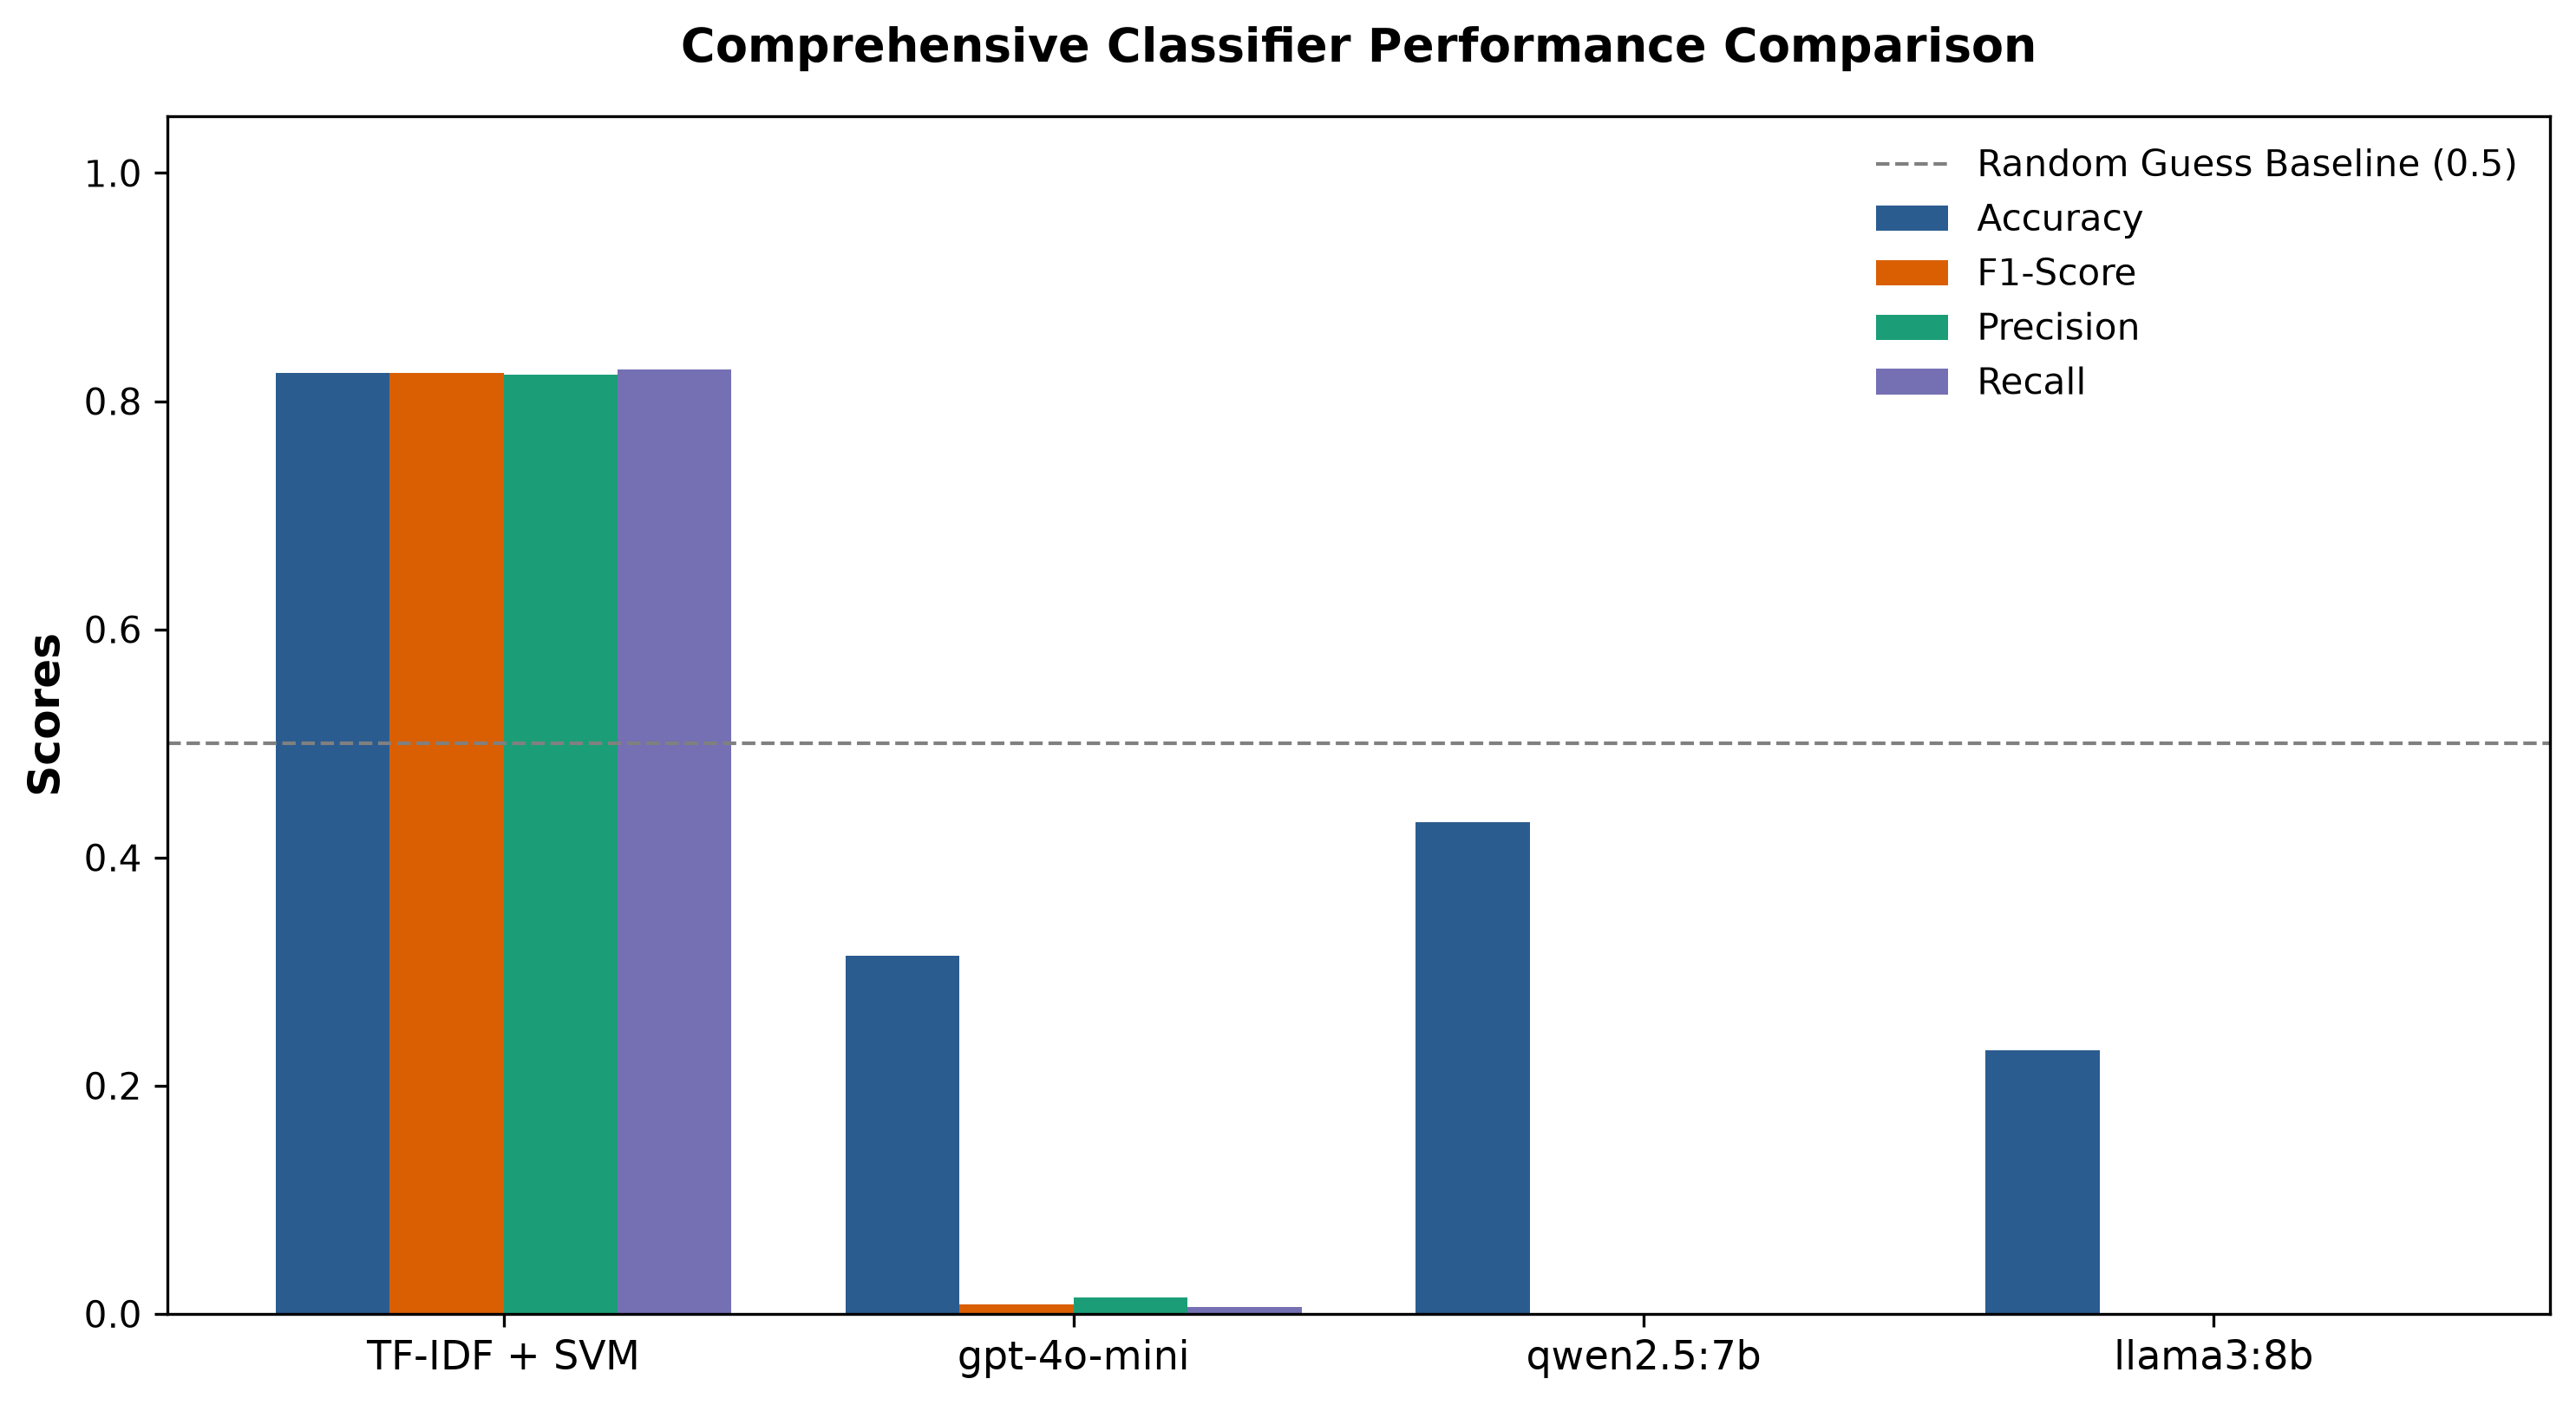

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Modeller ve metrikler
models = ['TF-IDF + SVM', 'gpt-4o-mini', 'qwen2.5:7b', 'llama3:8b']
accuracy = [0.825, 0.314, 0.431, 0.231]
f1_score = [0.825, 0.008, 0.000, 0.000]
precision = [0.823, 0.014, 0.000, 0.000]
recall = [0.828, 0.006, 0.000, 0.000]

x = np.arange(len(models))
width = 0.2  # narrowed to fit 4 columns

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

rects1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#2b5c8f')
rects2 = ax.bar(x - 0.5*width, f1_score, width, label='F1-Score', color='#d95f02')
rects3 = ax.bar(x + 0.5*width, precision, width, label='Precision', color='#1b9e77')
rects4 = ax.bar(x + 1.5*width, recall, width, label='Recall', color='#7570b3')

ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Classifier Performance Comparison', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random Guess Baseline (0.5)')
ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right')

plt.tight_layout()
plt.savefig('comprehensive_classifier_performance.png', dpi=300)
plt.show()

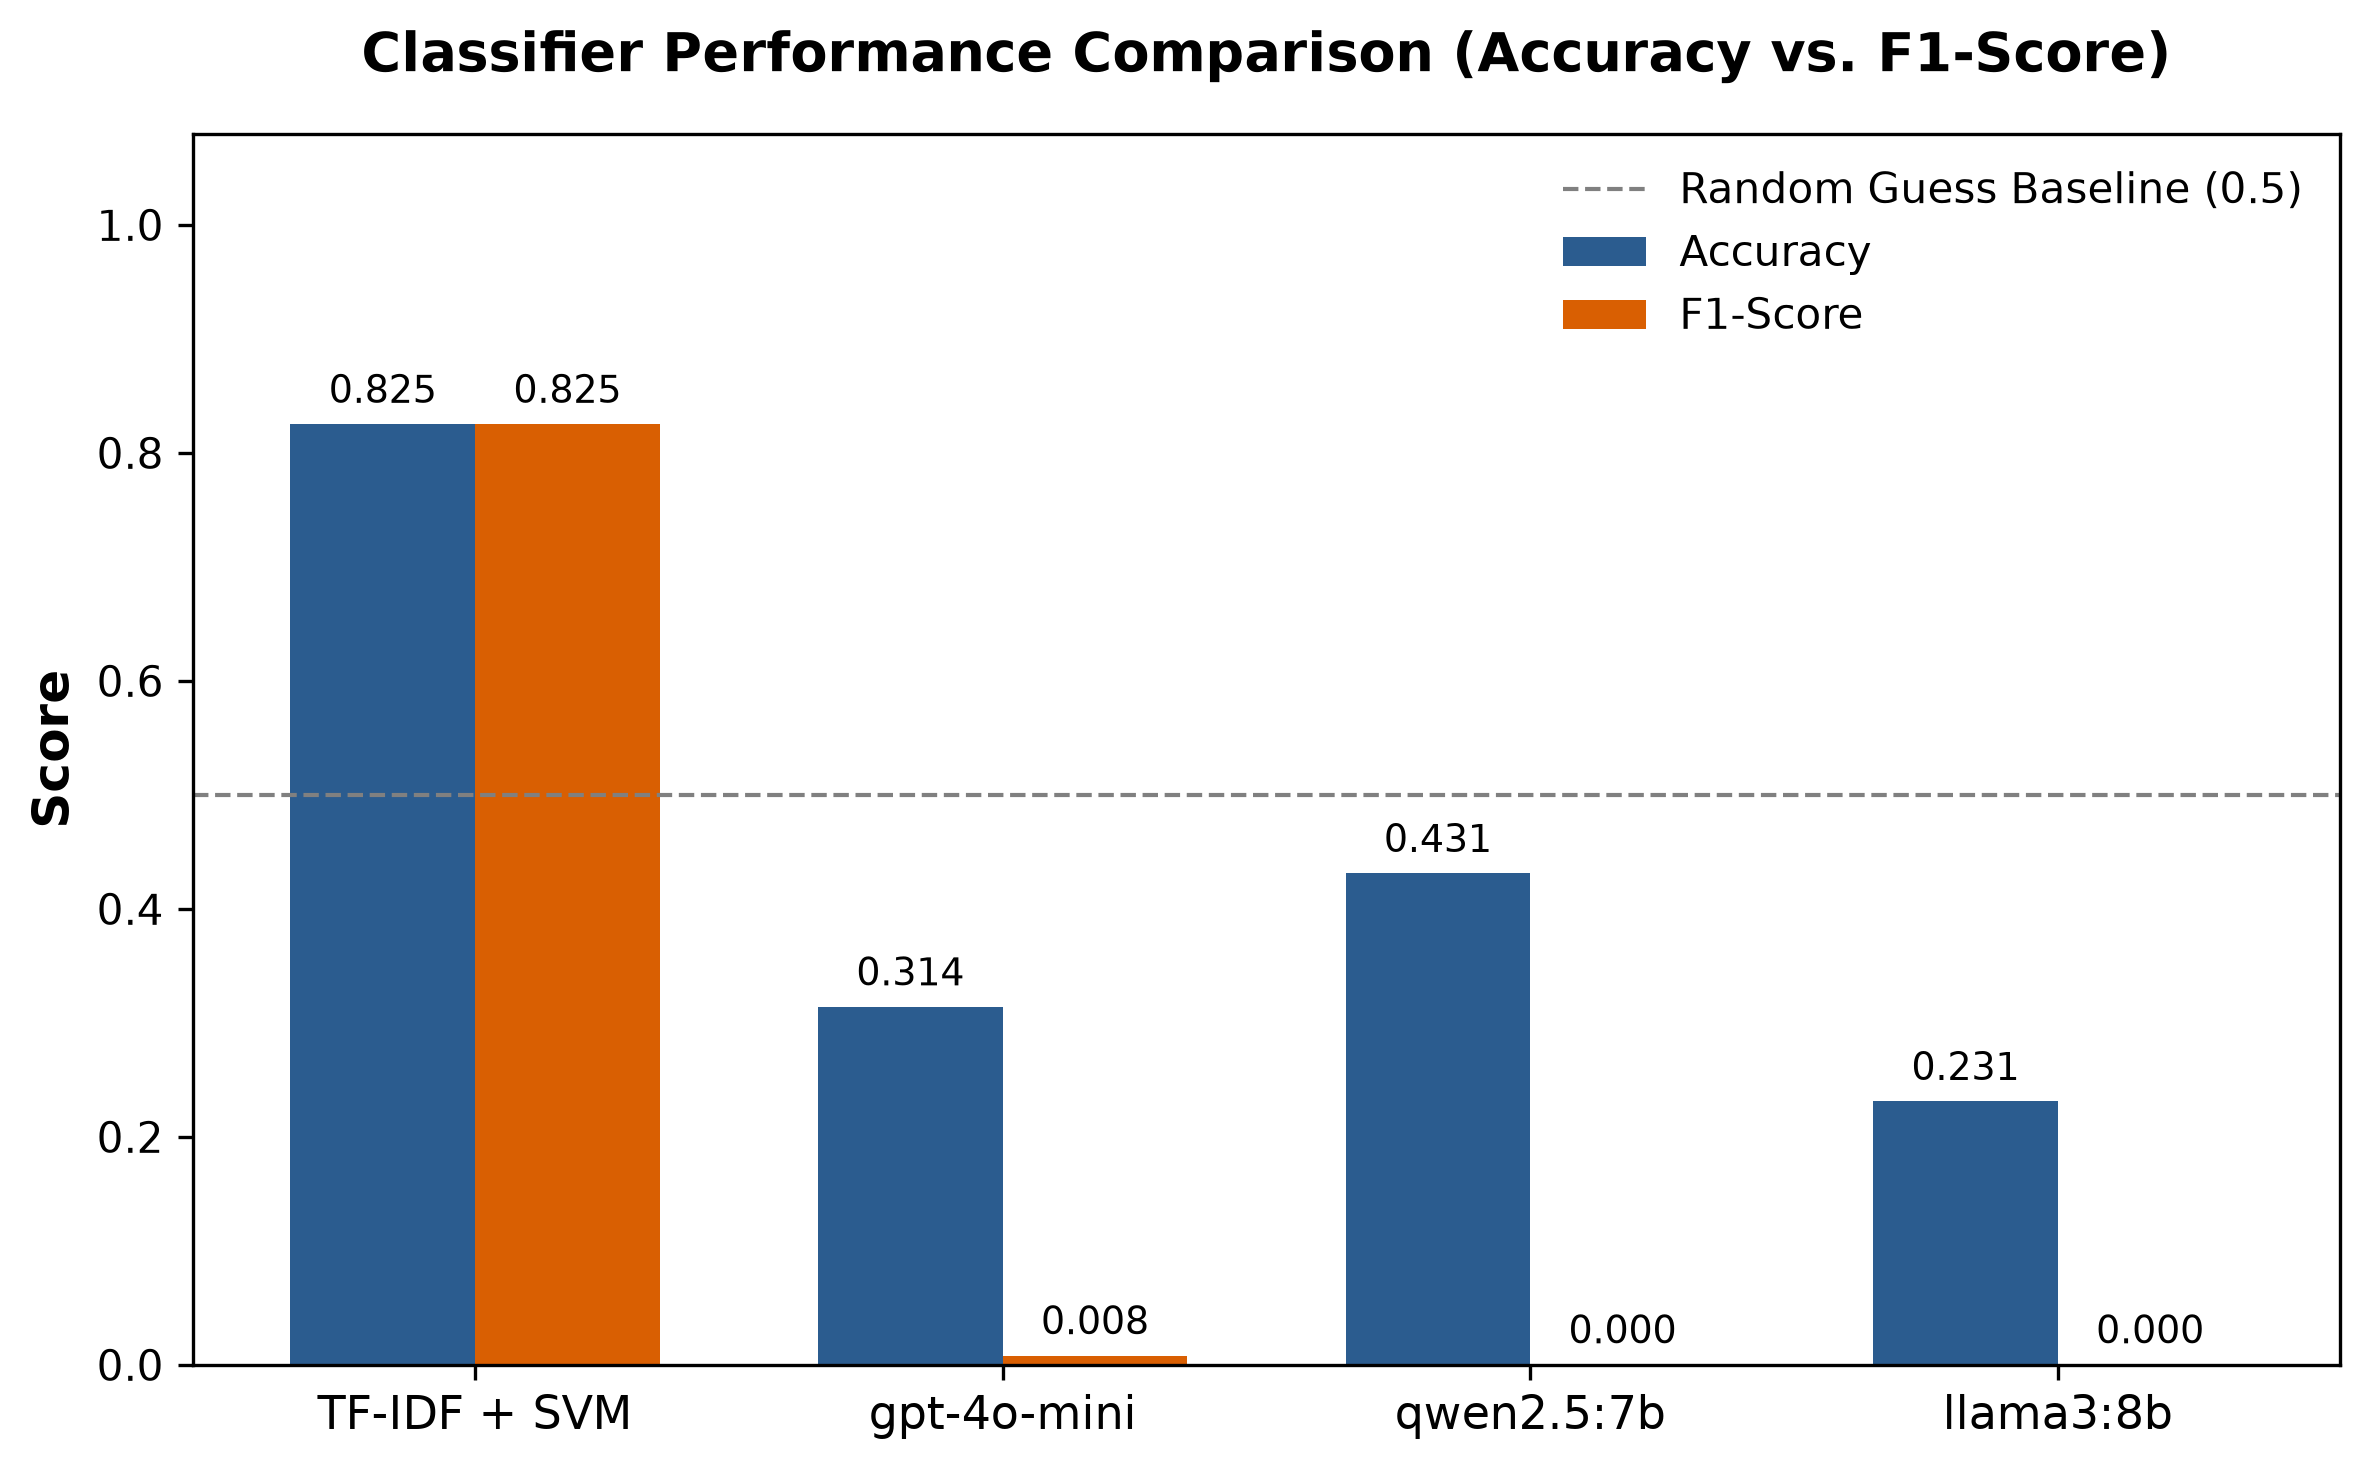

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Models and main metrics (Accuracy and F1-Score)
models = ['TF-IDF + SVM', 'gpt-4o-mini', 'qwen2.5:7b', 'llama3:8b']
accuracy = [0.825, 0.314, 0.431, 0.231]
f1_score = [0.825, 0.008, 0.000, 0.000]

x = np.arange(len(models))
width = 0.35  # good ratio for two bars

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#2b5c8f')
rects2 = ax.bar(x + width/2, f1_score, width, label='F1-Score', color='#d95f02')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Classifier Performance Comparison (Accuracy vs. F1-Score)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.08)  # leave room at top for labels
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random Guess Baseline (0.5)')
ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right')

# Function to print values above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('clean_classifier_performance.png', dpi=300)
plt.show()

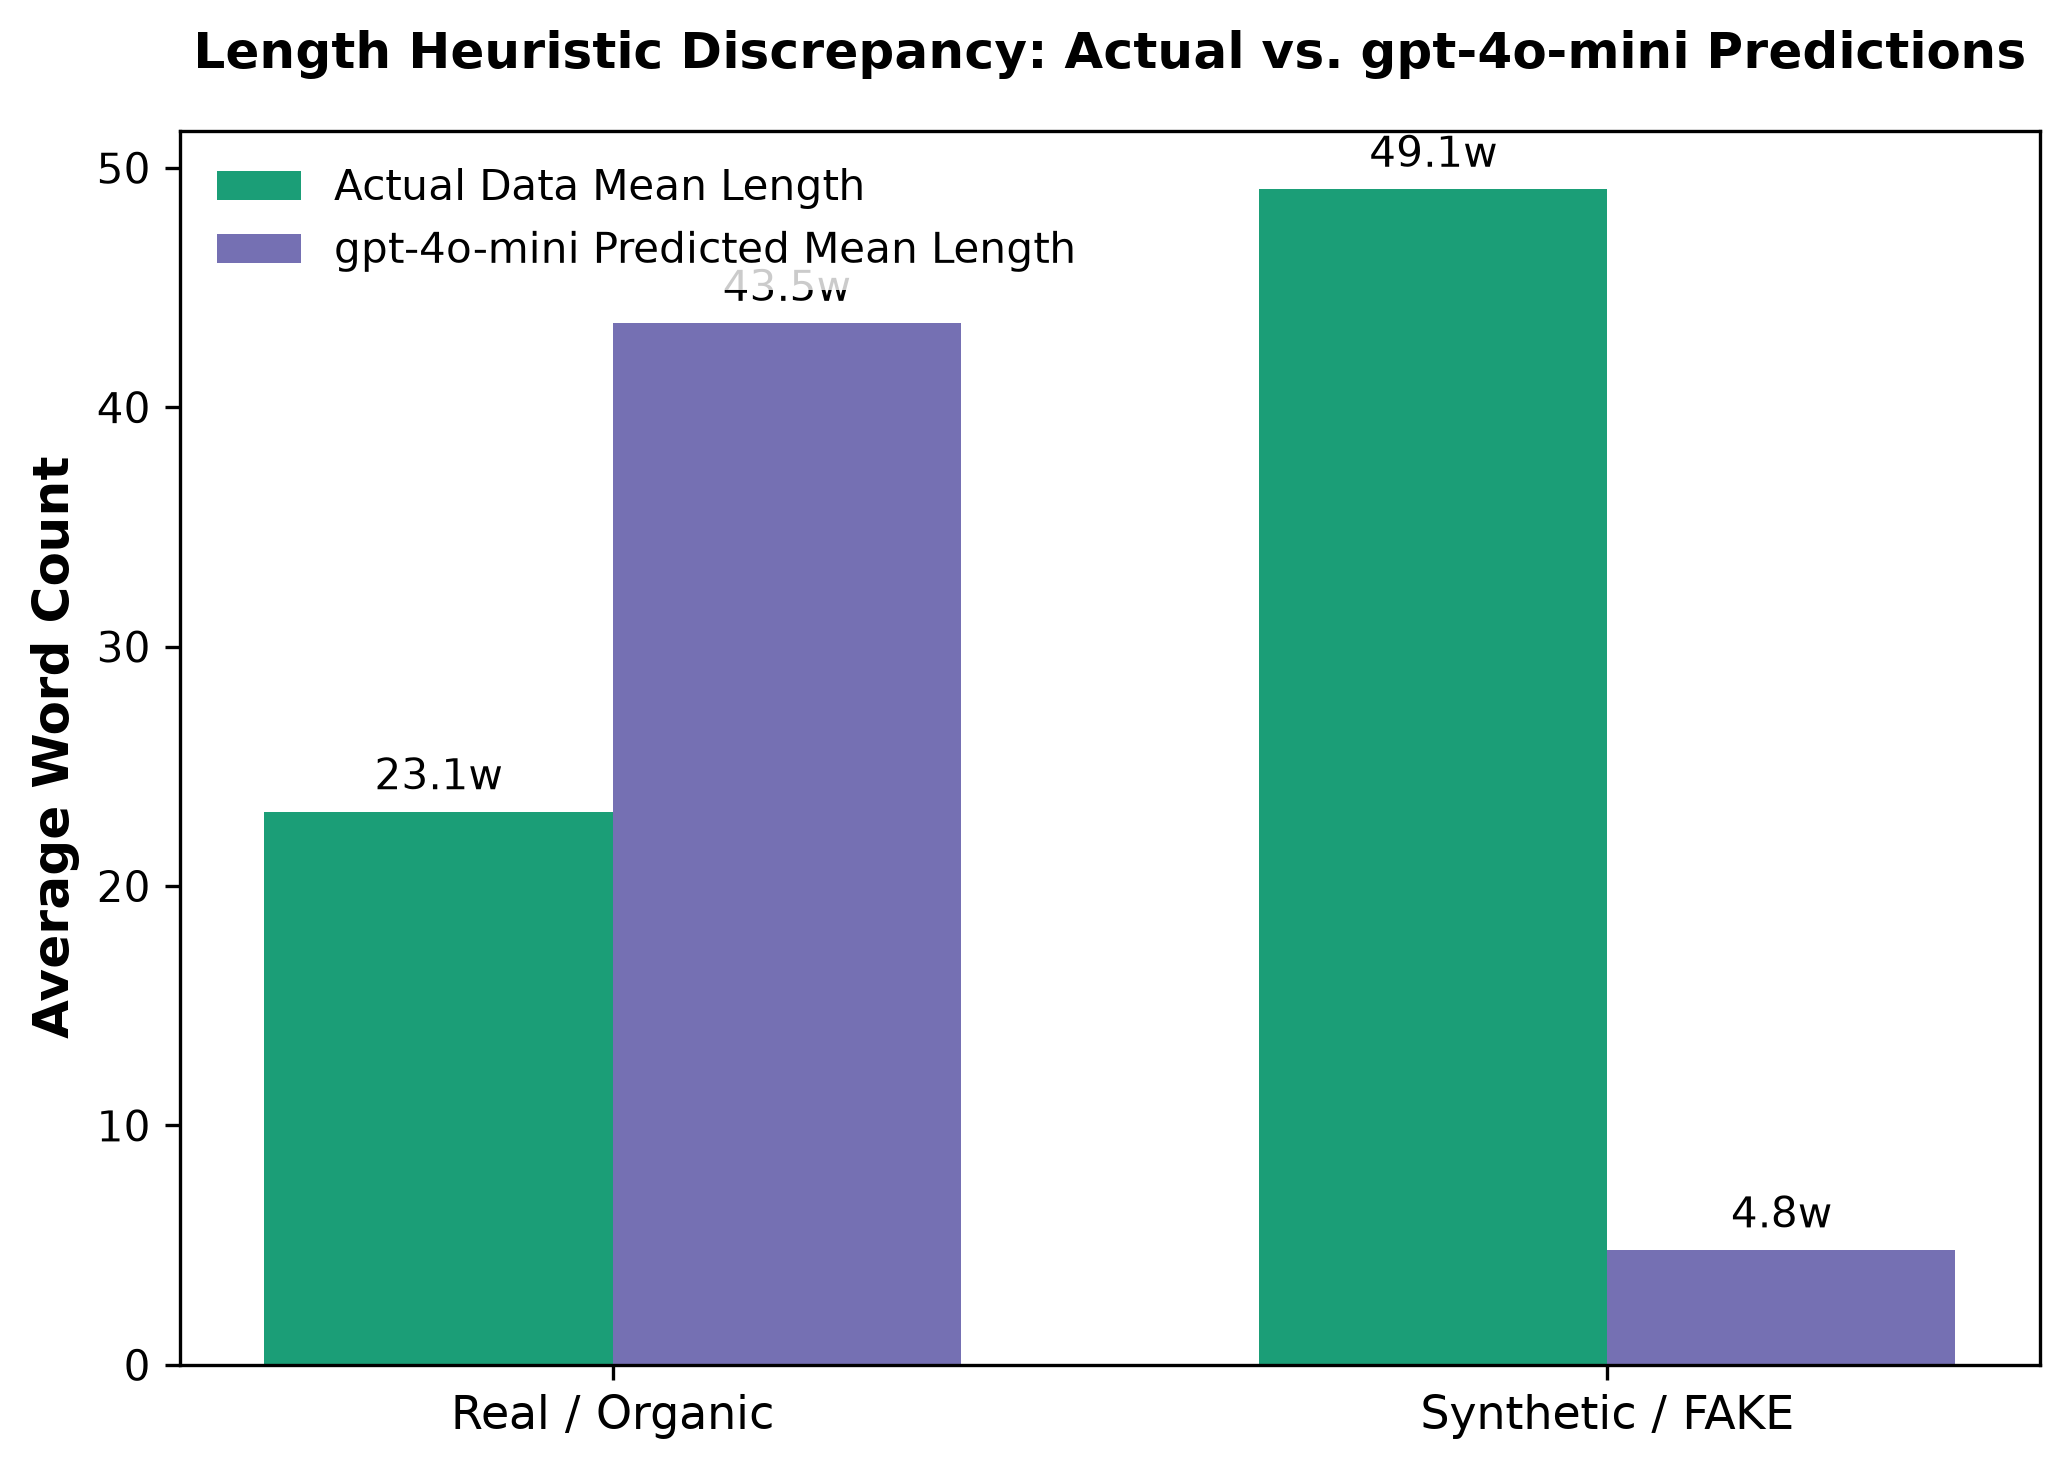

In [58]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Real / Organic', 'Synthetic / FAKE']
true_lengths = [23.1, 49.1]
pred_gpt_lengths = [43.5, 4.8]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
rects1 = ax.bar(x - width/2, true_lengths, width, label='Actual Data Mean Length', color='#1b9e77')
rects2 = ax.bar(x + width/2, pred_gpt_lengths, width, label='gpt-4o-mini Predicted Mean Length', color='#7570b3')

ax.set_ylabel('Average Word Count', fontsize=12, fontweight='bold')
ax.set_title('Length Heuristic Discrepancy: Actual vs. gpt-4o-mini Predictions', fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(frameon=True, facecolor='white', edgecolor='none')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}w',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('length_heuristic_comparison.png', dpi=300)
plt.show()

In [18]:
# Let's look at the models' FULL raw response (before parsing) on 5 sample rows
sample_check = test_df.sample(5, random_state=1)

for _, row in sample_check.iterrows():
    prompt = CLASSIFY_PROMPT.format(text=row["text"][:800])
    
    raw_gpt = client.chat.completions.create(
        model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], max_tokens=15, temperature=0
    ).choices[0].message.content
    
    raw_qwen = ollama.chat(model="qwen2.5:7b", messages=[{"role": "user", "content": prompt}])["message"]["content"]
    raw_llama = ollama.chat(model="llama3:8b", messages=[{"role": "user", "content": prompt}])["message"]["content"]
    
    print("TRUE:", "FAKE" if row["is_synthetic"] else "REAL")
    print("RAW gpt-4o-mini:", repr(raw_gpt))
    print("RAW qwen2.5:7b:", repr(raw_qwen))
    print("RAW llama3:8b:", repr(raw_llama))
    print("---")

TRUE: REAL
RAW gpt-4o-mini: 'REAL'
RAW qwen2.5:7b: 'REAL'
RAW llama3:8b: 'REAL'
---
TRUE: REAL
RAW gpt-4o-mini: 'FAKE'
RAW qwen2.5:7b: 'REAL'
RAW llama3:8b: 'FAKE'
---
TRUE: FAKE
RAW gpt-4o-mini: 'REAL'
RAW qwen2.5:7b: 'REAL'
RAW llama3:8b: 'REAL'
---
TRUE: FAKE
RAW gpt-4o-mini: 'REAL'
RAW qwen2.5:7b: 'REAL'
RAW llama3:8b: 'REAL'
---
TRUE: FAKE
RAW gpt-4o-mini: 'REAL'
RAW qwen2.5:7b: 'REAL'
RAW llama3:8b: 'REAL'
---


In [19]:
print("Prediction distribution:")
print("gpt-4o-mini:", results["pred_gpt4o_mini"].value_counts())
print("qwen2.5:7b:", results["pred_qwen2_5_7b"].value_counts())
print("llama3:8b:", results["pred_llama3_8b"].value_counts())

Prediction distribution:
gpt-4o-mini: pred_gpt4o_mini
0    291
1     69
Name: count, dtype: int64
qwen2.5:7b: pred_qwen2_5_7b
0    335
1     25
Name: count, dtype: int64
llama3:8b: pred_llama3_8b
0    263
1     97
Name: count, dtype: int64


In [20]:
# Look at the true-label distribution of the 69 rows gpt-4o-mini called "FAKE"
fake_predictions = results[results["pred_gpt4o_mini"] == 1]
print("When gpt-4o-mini said FAKE, true label was:")
print(fake_predictions["true_label"].value_counts())

# Same check for the other two models
for col in ["pred_qwen2_5_7b", "pred_llama3_8b"]:
    print(f"\nWhen {col} said FAKE, true label was:")
    print(results[results[col] == 1]["true_label"].value_counts())

When gpt-4o-mini said FAKE, true label was:
true_label
0    68
1     1
Name: count, dtype: int64

When pred_qwen2_5_7b said FAKE, true label was:
true_label
0    25
Name: count, dtype: int64

When pred_llama3_8b said FAKE, true label was:
true_label
0    97
Name: count, dtype: int64


In [21]:
results["word_count"] = results["text"].str.split().str.len()

print("Average word count by true label:")
print(results.groupby("true_label")["word_count"].mean())

print("\nAverage word count, split by what gpt-4o-mini predicted:")
print(results.groupby("pred_gpt4o_mini")["word_count"].mean())

Average word count by true label:
true_label
0    23.105556
1    49.144444
Name: word_count, dtype: float64

Average word count, split by what gpt-4o-mini predicted:
pred_gpt4o_mini
0    43.546392
1     4.826087
Name: word_count, dtype: float64


## 26. RQ3 Generator Comparison (old_weak vs. new_strong)

In [22]:
synthetic = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_injected_reviews.csv", encoding="utf-8-sig")
synthetic["word_count"] = synthetic["text"].str.split().str.len()

print("Average word count by generator:")
print(synthetic.groupby("generator_label")["word_count"].mean())

Average word count by generator:
generator_label
new_strong    47.964444
old_weak      51.622222
Name: word_count, dtype: float64


In [23]:
import pandas as pd
import numpy as np

results = pd.read_csv(r"C:\Users\Admin\Downloads\rq2_classification_results.csv", encoding="utf-8-sig")

print("generator_label distribution:")
print(results["generator_label"].value_counts(dropna=False))

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array([p if p is not None and not pd.isna(p) else 0 for p in y_pred])
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(y_true)
    return {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy, "n": len(y_true)}

# Organic (REAL) rows, shared by both generator subsets
organic_rows = results[results["is_synthetic"] == False]

classifiers = ["pred_tfidf_svm", "pred_gpt4o_mini", "pred_qwen2_5_7b", "pred_llama3_8b"]

print("\n=== RQ3: Performance by Generator (old_weak vs. new_strong) ===\n")

for generator in ["old_weak", "new_strong"]:
    print(f"\n--- Generator: {generator} ---")
    generator_fake_rows = results[(results["is_synthetic"] == True) & (results["generator_label"] == generator)]
    subset = pd.concat([generator_fake_rows, organic_rows])

    for col in classifiers:
        metrics = compute_metrics(subset["true_label"], subset[col])
        print(f"{col}: precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, "
              f"f1={metrics['f1']:.3f}, accuracy={metrics['accuracy']:.3f}, n={metrics['n']}")

results_summary = []
for generator in ["old_weak", "new_strong"]:
    generator_fake_rows = results[(results["is_synthetic"] == True) & (results["generator_label"] == generator)]
    subset = pd.concat([generator_fake_rows, organic_rows])
    for col in classifiers:
        metrics = compute_metrics(subset["true_label"], subset[col])
        metrics["generator"] = generator
        metrics["classifier"] = col
        results_summary.append(metrics)

summary_df = pd.DataFrame(results_summary)
summary_df.to_csv(r"C:\Users\Admin\Downloads\rq3_generator_comparison.csv", index=False, encoding="utf-8-sig")
print("\nSaved: rq3_generator_comparison.csv")

generator_label distribution:
generator_label
organic       180
new_strong     90
old_weak       90
Name: count, dtype: int64

=== RQ3: Performance by Generator (old_weak vs. new_strong) ===


--- Generator: old_weak ---
pred_tfidf_svm: precision=0.677, recall=0.744, f1=0.709, accuracy=0.796, n=270
pred_gpt4o_mini: precision=0.000, recall=0.000, f1=0.000, accuracy=0.415, n=270
pred_qwen2_5_7b: precision=0.000, recall=0.000, f1=0.000, accuracy=0.574, n=270
pred_llama3_8b: precision=0.000, recall=0.000, f1=0.000, accuracy=0.307, n=270

--- Generator: new_strong ---
pred_tfidf_svm: precision=0.719, recall=0.911, f1=0.804, accuracy=0.852, n=270
pred_gpt4o_mini: precision=0.014, recall=0.011, f1=0.013, accuracy=0.419, n=270
pred_qwen2_5_7b: precision=0.000, recall=0.000, f1=0.000, accuracy=0.574, n=270
pred_llama3_8b: precision=0.000, recall=0.000, f1=0.000, accuracy=0.307, n=270

Saved: rq3_generator_comparison.csv


In [60]:
import pandas as pd

# Prepare the table data
data = [
    {"Classifier_Generator": "TF-IDF + SVM (old_weak)", "Precision": 0.677, "Recall": 0.744, "F1_Score": 0.709, "Accuracy": 0.796, "Sample_Size": 270},
    {"Classifier_Generator": "TF-IDF + SVM (new_strong)", "Precision": 0.719, "Recall": 0.911, "F1_Score": 0.804, "Accuracy": 0.852, "Sample_Size": 270},
    {"Classifier_Generator": "gpt-4o-mini (old_weak)", "Precision": 0.000, "Recall": 0.000, "F1_Score": 0.000, "Accuracy": 0.415, "Sample_Size": 270},
    {"Classifier_Generator": "gpt-4o-mini (new_strong)", "Precision": 0.014, "Recall": 0.011, "F1_Score": 0.013, "Accuracy": 0.419, "Sample_Size": 270},
    {"Classifier_Generator": "qwen2.5:7b (old_weak)", "Precision": 0.000, "Recall": 0.000, "F1_Score": 0.000, "Accuracy": 0.574, "Sample_Size": 270},
    {"Classifier_Generator": "qwen2.5:7b (new_strong)", "Precision": 0.000, "Recall": 0.000, "F1_Score": 0.000, "Accuracy": 0.574, "Sample_Size": 270},
    {"Classifier_Generator": "llama3:8b (old_weak)", "Precision": 0.000, "Recall": 0.000, "F1_Score": 0.000, "Accuracy": 0.307, "Sample_Size": 270},
    {"Classifier_Generator": "llama3:8b (new_strong)", "Precision": 0.000, "Recall": 0.000, "F1_Score": 0.000, "Accuracy": 0.307, "Sample_Size": 270}
]

df = pd.DataFrame(data)

# Key parameter that prevents character corruption: encoding='utf-8-sig'
df.to_csv('rq3_generator_performance_summary.csv', index=False, encoding='utf-8-sig')

print("CSV file saved successfully, no character corruption!")

CSV file saved successfully, no character corruption!


In [24]:
from math import sqrt

def two_proportion_ztest(x1, n1, x2, n2):
    p1, p2 = x1/n1, x2/n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (p1 - p2) / se
    from scipy.stats import norm  # if scipy.stats doesn't work, use the manual version below
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return z, p_value

# recall comparison: old_weak recall=0.744 (n=90) vs new_strong recall=0.911 (n=90)
x1 = round(0.744 * 90)  # number of correctly caught FAKEs for old_weak
x2 = round(0.911 * 90)  # number of correctly caught FAKEs for new_strong

z, p = two_proportion_ztest(x1, 90, x2, 90)
print(f"z={z:.3f}, p={p:.4f}")

z=-2.961, p=0.0031


## 27. RQ2(a)  Cross-Lingual (German) Test

In [25]:
import pandas as pd
import numpy as np
import time
import ollama
from openai import OpenAI
from tqdm import tqdm

client = OpenAI(api_key="sk-your-api-key")  # paste your own key

# ============================================================
# 1) Load data, select 180 bilingual organic rows
#    (excluding any rows already used in the RQ2(b)/RQ3 test set,
#    to avoid overlap)
# ============================================================
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig", low_memory=False)
existing_test = pd.read_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", encoding="utf-8-sig")

used_asins_or_texts = set(existing_test["text"].tolist())

organic_bilingual = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] != "en") &
    (combined["translation_status"].isin(["translated", "translated_cached", "translated_mymemory", "translated_mymemory_chunked"])) &
    (combined["text_en"].notna()) &
    (combined["text"].notna()) &
    (~combined["text"].isin(used_asins_or_texts))
].copy()

print("Available bilingual organic rows (excluding RQ2b/RQ3 test overlap):", len(organic_bilingual))

rq2a_sample = organic_bilingual.sample(n=180, random_state=42).copy()
print("\nLanguage distribution:")
print(rq2a_sample["detected_lang"].value_counts())

rq2a_sample.to_csv(r"C:\Users\Admin\Downloads\rq2a_sample.csv", index=False, encoding="utf-8-sig")
print("Saved: rq2a_sample.csv")

Available bilingual organic rows (excluding RQ2b/RQ3 test overlap): 18486

Language distribution:
detected_lang
de    157
id      5
no      3
it      3
fr      3
nl      2
da      1
pt      1
sl      1
es      1
tr      1
so      1
af      1
Name: count, dtype: int64
Saved: rq2a_sample.csv


In [26]:
# ============================================================
# 1) Load data, select 180 GERMAN-ONLY organic rows
#    (excluding any rows already used in the RQ2(b)/RQ3 test set)
# ============================================================
combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig", low_memory=False)
existing_test = pd.read_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", encoding="utf-8-sig")

used_texts = set(existing_test["text"].tolist())

organic_bilingual = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "de") &  # German only, per supervisor decision
    (combined["translation_status"].isin(["translated", "translated_cached", "translated_mymemory", "translated_mymemory_chunked"])) &
    (combined["text_en"].notna()) &
    (combined["text"].notna()) &
    (~combined["text"].isin(used_texts))
].copy()

print("Available German organic rows (excluding RQ2b/RQ3 test overlap):", len(organic_bilingual))

rq2a_sample = organic_bilingual.sample(n=180, random_state=42).copy()
print("\nLanguage distribution (should be 100% German):")
print(rq2a_sample["detected_lang"].value_counts())

rq2a_sample.to_csv(r"C:\Users\Admin\Downloads\rq2a_sample.csv", index=False, encoding="utf-8-sig")
print("Saved: rq2a_sample.csv")

Available German organic rows (excluding RQ2b/RQ3 test overlap): 16085

Language distribution (should be 100% German):
detected_lang
de    180
Name: count, dtype: int64
Saved: rq2a_sample.csv


In [27]:
import pandas as pd
import numpy as np

combined = pd.read_csv(r"C:\Users\Admin\Downloads\combined_silver_labeled.csv", encoding="utf-8-sig", low_memory=False)
existing_test = pd.read_csv(r"C:\Users\Admin\Downloads\final_test_set.csv", encoding="utf-8-sig")

used_texts = set(existing_test["text"].tolist())

organic_bilingual = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "de") &
    (combined["translation_status"].isin(["translated", "translated_cached", "translated_mymemory", "translated_mymemory_chunked"])) &
    (combined["text_en"].notna()) &
    (combined["text"].notna()) &
    (~combined["text"].isin(used_texts))
].copy()

print("Available German organic rows:", len(organic_bilingual))

rq2a_sample = organic_bilingual.sample(n=180, random_state=42).copy()
print("Language distribution:")
print(rq2a_sample["detected_lang"].value_counts())

rq2a_sample.to_csv(r"C:\Users\Admin\Downloads\rq2a_sample.csv", index=False, encoding="utf-8-sig")
print("Saved: rq2a_sample.csv")

Available German organic rows: 16085
Language distribution:
detected_lang
de    180
Name: count, dtype: int64
Saved: rq2a_sample.csv


In [28]:
import time
import ollama
from openai import OpenAI
from tqdm import tqdm

client = OpenAI(api_key="sk-your-api-key")  # paste your own key

CLASSIFY_PROMPT = """Read the following Amazon product review:

"{text}"

Is this review likely to be fake/AI-generated, or a genuine review written by a real customer?
Respond with EXACTLY one word: FAKE or REAL."""

def classify_openai(text, model="gpt-4o-mini", max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=str(text)[:800])
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=5,
                temperature=0,
            )
            answer = response.choices[0].message.content.strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

def classify_ollama(text, model, max_retries=3):
    prompt = CLASSIFY_PROMPT.format(text=str(text)[:800])
    for attempt in range(max_retries):
        try:
            response = ollama.chat(model=model, messages=[{"role": "user", "content": prompt}])
            answer = response["message"]["content"].strip().upper()
            return 1 if "FAKE" in answer else 0
        except Exception:
            time.sleep(2)
    return None

print("Classifier functions ready.")

Classifier functions ready.


In [29]:
import re

def tokenize(text):
    return re.findall(r"[a-z]+", str(text).lower())

def build_vocab(texts, max_features=500):
    doc_freq = {}
    for text in texts:
        words = set(tokenize(text))
        for w in words:
            doc_freq[w] = doc_freq.get(w, 0) + 1
    n_docs = len(texts)
    idf = {w: np.log(n_docs / (1 + df)) for w, df in doc_freq.items()}
    top_words = sorted(idf.items(), key=lambda x: doc_freq[x[0]], reverse=True)[:max_features]
    vocab = {w: i for i, (w, _) in enumerate(top_words)}
    return vocab, idf

def vectorize(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)))
    for row, text in enumerate(texts):
        words = tokenize(text)
        if not words:
            continue
        tf = {}
        for w in words:
            tf[w] = tf.get(w, 0) + 1
        for w, count in tf.items():
            if w in vocab:
                X[row, vocab[w]] = (count / len(words)) * idf.get(w, 0)
    return X

def train_linear_svm(X, y, lr=0.01, epochs=200, C=1.0):
    n, d = X.shape
    y_signed = np.where(y == 1, 1, -1)
    w = np.zeros(d)
    b = 0.0
    for epoch in range(epochs):
        margins = y_signed * (X @ w + b)
        misclassified = margins < 1
        grad_w = w - C * (X[misclassified].T @ y_signed[misclassified]) if misclassified.sum() > 0 else w
        grad_b = -C * y_signed[misclassified].sum() if misclassified.sum() > 0 else 0
        w -= lr * grad_w / n
        b -= lr * grad_b / n
    return w, b

def svm_predict(texts, vocab, idf, w, b):
    X = vectorize(texts, vocab, idf)
    scores = X @ w + b
    return (scores > 0).astype(int)

train_df = pd.read_csv(r"C:\Users\Admin\Downloads\synthetic_train.csv", encoding="utf-8-sig")
organic_pool = combined[
    (combined["source_batch"].isin(["batch1", "batch2"])) &
    (combined["detected_lang"] == "en") &
    (combined["core_silver_fake"] == False)
]
organic_train_sample = organic_pool.sample(n=len(train_df), random_state=42)["text"].tolist()

train_texts = train_df["text"].tolist() + organic_train_sample
train_labels = [1]*len(train_df) + [0]*len(organic_train_sample)

vocab, idf = build_vocab(train_texts, max_features=500)
X_train = vectorize(train_texts, vocab, idf)
y_train = np.array(train_labels)
w_svm, b_svm = train_linear_svm(X_train, y_train)
print("TF-IDF+SVM trained.")

TF-IDF+SVM trained.


In [30]:
results = rq2a_sample.copy()

results["pred_orig_tfidf_svm"] = svm_predict(results["text"].tolist(), vocab, idf, w_svm, b_svm)
results["pred_en_tfidf_svm"] = svm_predict(results["text_en"].tolist(), vocab, idf, w_svm, b_svm)

pred_orig_gpt, pred_en_gpt = [], []
pred_orig_qwen, pred_en_qwen = [], []
pred_orig_llama, pred_en_llama = [], []

for i, (_, row) in enumerate(tqdm(results.iterrows(), total=len(results), desc="RQ2(a): classifying original + translated")):
    pred_orig_gpt.append(classify_openai(row["text"], "gpt-4o-mini"))
    pred_en_gpt.append(classify_openai(row["text_en"], "gpt-4o-mini"))

    pred_orig_qwen.append(classify_ollama(row["text"], "qwen2.5:7b"))
    pred_en_qwen.append(classify_ollama(row["text_en"], "qwen2.5:7b"))

    pred_orig_llama.append(classify_ollama(row["text"], "llama3:8b"))
    pred_en_llama.append(classify_ollama(row["text_en"], "llama3:8b"))

    time.sleep(0.2)

    if (i + 1) % 20 == 0:
        temp = results.iloc[:len(pred_orig_gpt)].copy()
        temp["pred_orig_gpt4o_mini"] = pred_orig_gpt
        temp["pred_en_gpt4o_mini"] = pred_en_gpt
        temp["pred_orig_qwen2_5_7b"] = pred_orig_qwen
        temp["pred_en_qwen2_5_7b"] = pred_en_qwen
        temp["pred_orig_llama3_8b"] = pred_orig_llama
        temp["pred_en_llama3_8b"] = pred_en_llama
        temp.to_csv(r"C:\Users\Admin\Downloads\rq2a_results_PARTIAL.csv", index=False, encoding="utf-8-sig")

results["pred_orig_gpt4o_mini"] = pred_orig_gpt
results["pred_en_gpt4o_mini"] = pred_en_gpt
results["pred_orig_qwen2_5_7b"] = pred_orig_qwen
results["pred_en_qwen2_5_7b"] = pred_en_qwen
results["pred_orig_llama3_8b"] = pred_orig_llama
results["pred_en_llama3_8b"] = pred_en_llama

results.to_csv(r"C:\Users\Admin\Downloads\rq2a_results.csv", index=False, encoding="utf-8-sig")
print("\nSaved: rq2a_results.csv")

RQ2(a): classifying original + translated: 100%|██████████| 180/180 [1:21:31<00:00, 27.18s/it]


Saved: rq2a_results.csv


In [31]:
def mcnemar_manual(pred_a, pred_b):
    a = np.array([p if p is not None else 0 for p in pred_a])
    b = np.array([p if p is not None else 0 for p in pred_b])
    b01 = ((a == 0) & (b == 1)).sum()
    b10 = ((a == 1) & (b == 0)).sum()
    n = b01 + b10
    if n == 0:
        return {"b01": 0, "b10": 0, "chi2": 0, "p_approx": 1.0}
    chi2 = ((abs(b01 - b10) - 1) ** 2) / n
    p_approx = np.exp(-chi2 / 2) if chi2 < 20 else 0.0
    return {"b01": b01, "b10": b10, "chi2": chi2, "p_approx": p_approx}

print("=== RQ2(a): McNemar's Test Results (original-language vs. translated) ===\n")
classifier_pairs = {
    "TF-IDF+SVM": ("pred_orig_tfidf_svm", "pred_en_tfidf_svm"),
    "gpt-4o-mini": ("pred_orig_gpt4o_mini", "pred_en_gpt4o_mini"),
    "qwen2.5:7b": ("pred_orig_qwen2_5_7b", "pred_en_qwen2_5_7b"),
    "llama3:8b": ("pred_orig_llama3_8b", "pred_en_llama3_8b"),
}

for name, (col_orig, col_en) in classifier_pairs.items():
    result = mcnemar_manual(results[col_orig], results[col_en])
    agree_rate = (results[col_orig] == results[col_en]).mean()
    print(f"{name}: agreement rate={agree_rate:.3f}, orig->en shifts to FAKE={result['b01']}, "
          f"orig->en shifts to REAL={result['b10']}, chi2={result['chi2']:.3f}, p(approx)={result['p_approx']:.4f}")

=== RQ2(a): McNemar's Test Results (original-language vs. translated) ===

TF-IDF+SVM: agreement rate=0.744, orig->en shifts to FAKE=20, orig->en shifts to REAL=26, chi2=0.543, p(approx)=0.7621
gpt-4o-mini: agreement rate=0.817, orig->en shifts to FAKE=31, orig->en shifts to REAL=2, chi2=23.758, p(approx)=0.0000
qwen2.5:7b: agreement rate=0.922, orig->en shifts to FAKE=5, orig->en shifts to REAL=9, chi2=0.643, p(approx)=0.7251
llama3:8b: agreement rate=0.711, orig->en shifts to FAKE=8, orig->en shifts to REAL=44, chi2=23.558, p(approx)=0.0000


## 28. McNemar's Test Results and Chart

In [56]:
import pandas as pd

# Word and Excel compatible, clean academic headers
data = {
    'Classifier': ['TF-IDF + SVM', 'gpt-4o-mini', 'qwen2.5:7b', 'llama3:8b'],
    'Agreement Rate': [0.744, 0.817, 0.922, 0.711],
    'Shift to FAKE': [20, 31, 5, 8],
    'Shift to REAL': [26, 2, 9, 44],
    'χ² Statistic': [0.543, 23.758, 0.643, 23.558],
    'p-value': [0.7621, '< 0.001', 0.7251, '< 0.001']
}

df = pd.DataFrame(data)

# Save as CSV
file_path = 'mcnemar_results_clean.csv'
df.to_csv(file_path, index=False, encoding='utf-8-sig')  # avoids character/symbol corruption utf-8-sig

print(f"File ready: {file_path}")

File ready: mcnemar_results_clean.csv


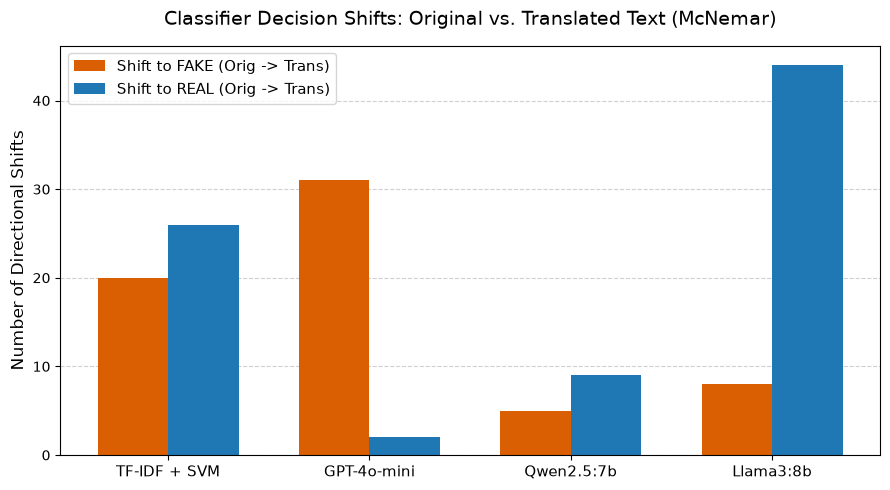

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Our data
models = ['TF-IDF + SVM', 'GPT-4o-mini', 'Qwen2.5:7b', 'Llama3:8b']
shifts_to_fake = [20, 31, 5, 8]
shifts_to_real = [26, 2, 9, 44]

x = np.arange(len(models))
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(9, 5))

# Build the bars
rects1 = ax.bar(x - width/2, shifts_to_fake, width, label='Shift to FAKE (Orig -> Trans)', color='#d95f02')
rects2 = ax.bar(x + width/2, shifts_to_real, width, label='Shift to REAL (Orig -> Trans)', color='#1f78b4')

# Axis labels and title
ax.set_ylabel('Number of Directional Shifts', fontsize=12)
ax.set_title('Classifier Decision Shifts: Original vs. Translated Text (McNemar)', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)

# Grid lines (a nice touch for the background)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

fig.tight_layout()

# Save at high resolution (set your own file path if you like)
plt.savefig("mcnemar_directional_shifts.png", dpi=300)
plt.show()